# Recommendation System for Amazon Musical Instruments

**Data Mining Homework3 — YZM2022**

Bu çalışmada Amazon Reviews 2023 verisinin Musical Instruments kategorisi üzerinde recommendation system geliştirildi. Üç ana yaklaşımı (content-based, collaborative, hybrid) karşılaştırıldı, üç farklı feature selection tekniği uyguladık ve sonuçları 5-fold cross validation ile doğruladık.

## Çalışmanın Özeti

- **Dataset:** Amazon Reviews 2023 Musical Instruments (2014-2023), 5-core filtreleme sonrası 473,647 etkileşim, 53,127 kullanıcı, 23,158 ürün
- **Modeller:** TF-IDF, Sentence-BERT, CLIP, User-based CF, Item-based CF, SVD, ALS, Weighted Hybrid, Multimodal Ensemble
- **Feature Selection:** Chi-square, Mutual Information, ReliefF
- **Evaluation:** 5-fold cross validation; P@K, R@K, NDCG@K, MAP@K, Coverage, MAE, RMSE
- **Cold-start analysis:** 1-review ve 2-review kullanıcılar için ayrı değerlendirme

## İçerik

1. Giriş
2. Dataset
3. Exploratory Data Analysis
4. Recommendation Models
5. Evaluation
6. Discussion


# 1. Giriş

Recommendation system'ler, kullanıcılara büyük ürün havuzları içinden ilgilenebilecekleri öğeleri öneren makine öğrenmesi sistemleridir. Amazon, Netflix, Spotify gibi platformların temel bileşenidir.

Bu çalışmada Amazon Reviews 2023 verisinin **Musical Instruments** kategorisi üzerinde farklı recommendation yaklaşımlarını karşılaştırdık. Musical instruments kategorisini seçme nedenimiz:
- Sparsity oranı yüksek (%99.96)
- Hem metin (ürün açıklamaları, yorumlar) hem görsel (ürün fotoğrafları) içerik mevcut
- Literatürde daha az çalışılmış bir kategori

## 1.1 Problem Tanımı

Bir kullanıcının geçmiş rating'lerine ve yorumlarına bakarak, daha önce etkileşime girmediği ürünler arasından **top-K öneri listesi** üretmek istiyoruz. Sistemin çözmesi gereken üç temel zorluk:

1. **Sparsity:** Kullanıcı-ürün matrisinin %99.96'ünden fazlası boş.
- Yani devasa bir müzik mağazası düşünün; her birimiz on binlerce üründen sadece birkaç tanesine dokunuyoruz, geri kalan tüm raflar bizim profilimizde tamamen boş/bilinmez olarak kalıyor.


2. **Cold-start:** Yeni kullanıcılar veya az rating'i olan ürünler için yeterli veri yok.
- Tıpkı dükkandan içeri yeni girmiş ve henüz hiçbir şeye bakmamış bir müşteriye ne önereceğimizi bilememe problemi gibi.


3. **Diversity vs Accuracy:** Sadece popüler ürün önermek doğruluğu artırır ama keşfi azaltır.


## 1.2 Yaklaşımımız

Üç ana paradigmayı kurup karşılaştırdık:

- **Content-Based Filtering:** Ürünlerin metin (TF-IDF, Sentence-BERT) ve görsel (CLIP) içeriğine bakarak benzerlik bulur.
- Özetle: "Sen daha önce bu marka ahşap bir klasik gitar almıştın, bak burada yapısal olarak ona çok benzeyen başka gitarlar var" mantığıdır.
- **Collaborative Filtering:** Kullanıcıların etkileşim örüntülerinden öğrenir.
- Özetle: "Seninle geçmişte tamamen aynı gitar tellerini ve penaları satın almış bir başka müşteri, şu amfiyi de çok sevdi; senin de hoşuna gidebilir" diyerek kalabalıktan öğrenme yöntemidir.
- **Hybrid:** Yukarıdaki iki yaklaşımı birleştirir.

Ek olarak, kullanıcı yorumlarındaki sentiment bilgisini rating'le birleştiren bir **sentiment-weighted rating** denedik.


# 2. Dataset

## 2.1 Veri Kaynağı

[McAuley-Lab Amazon Reviews 2023](https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023) verisinin Musical Instruments alt kümesini kullandık. Orijinal veri 1999-2023 arasını kapsar ve yaklaşık 3 milyon etkileşim içerir. Her etkileşimde user_id, parent_asin, rating (1-5), yorum metni, tarih, verified_purchase ve helpful_vote bilgisi mevcut. Ürün metadata'sında title, description, features, categories, store ve görsel URL'leri var.

## 2.2 Sampling Stratejisi

Veriyi makul sürede işleyebilmek ve daha kaliteli bir alt küme elde etmek için şu adımları uyguladık:

1. **Tarih filtresi:** 2014-01-01 ile 2023-09-12 arası seçildi. Modern mobil-sonrası dönemi yansıtıyor.
2. **Cold-start test seti ayrımı:** 1-2 review'ı olan kullanıcılardan 5,000 tanesi, 5-core filtreleme uygulanmadan ÖNCE ayrıldı. Bunlar daha sonra cold-start değerlendirmesinde kullanıldı.
3. **İteratif 5-core filtreleme:** Her kullanıcının ≥5 ürünle, her ürünün ≥5 kullanıcıyla etkileşimi olacak şekilde filtreyi tekrar tekrar uyguladık.
4. **Tekrarlanabilirlik:** Tüm rastgele işlemlerde seed=42 kullanıldı.

Hazırladığımız veri Hugging Face Hub'a yüklendi: `oyku-tugana/amazon-musical-instruments-2014-2023-5core`

## 2.3 Setup ve Veri Yükleme


In [1]:
# Temel kutuphaneler
import os, pickle, time, json
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix, load_npz
from scipy.stats import spearmanr
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize as sk_normalize
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_selection import chi2, mutual_info_classif, SelectKBest
from sklearn.model_selection import KFold
import implicit

import nltk
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from huggingface_hub import hf_hub_download
from scipy.sparse import vstack as sparse_vstack


# Project root'u otomatik bul
# results/embeddings/ klasoru hangi parent'ta bulunursa orasini root say.
_cwd = Path('.').resolve()
PROJECT_ROOT = _cwd
_search = _cwd
for _ in range(3):  # en fazla 3 seviye yukari bak
    if (_search / 'results' / 'embeddings').is_dir():
        PROJECT_ROOT = _search
        break
    if _search.parent == _search:
        break
    _search = _search.parent

print(f'Project root: {PROJECT_ROOT}')

DATA_DIR     = PROJECT_ROOT / 'data'
RESULTS_DIR  = PROJECT_ROOT / 'results'
FIGURES_DIR  = RESULTS_DIR / 'figures'
TABLES_DIR   = RESULTS_DIR / 'tables'
EMBEDDINGS_DIR = RESULTS_DIR / 'embeddings'
CACHE_DIR    = DATA_DIR / 'cache'

for d in [DATA_DIR, RESULTS_DIR, FIGURES_DIR, TABLES_DIR, EMBEDDINGS_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

HF_DATASET_REPO = 'oyku-tugana/amazon-musical-instruments-2014-2023-5core'

SEED = 42
K_VALUES = [5, 10, 20]
N_FOLDS = 5
TEST_MONTHS = 12
TFIDF_MAX_FEATURES = 5000
SBERT_MODEL = 'all-MiniLM-L6-v2'
CLIP_MODEL  = 'openai/clip-vit-base-patch32'

np.random.seed(SEED)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.bbox'] = 'tight'

# NLTK stopwords
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords', quiet=True)

print(f'Setup complete. Seed={SEED}, K_VALUES={K_VALUES}, N_FOLDS={N_FOLDS}')


Project root: /Users/toyku/PycharmProjects/DataMining_hw3
Setup complete. Seed=42, K_VALUES=[5, 10, 20], N_FOLDS=5


In [2]:
# ===================================================================
# Yardimci fonksiyonlar
# ===================================================================

# --- data_utils ---
_PARQUET_PATHS = {
    'interactions': 'interactions/train-00000-of-00001.parquet',
    'cold_start':   'cold_start/train-00000-of-00001.parquet',
    'items':        'items/train-00000-of-00001.parquet',
}

def _download_parquet(key):
    return hf_hub_download(
        repo_id=HF_DATASET_REPO, filename=_PARQUET_PATHS[key],
        repo_type='dataset', cache_dir=str(CACHE_DIR))

def load_interactions():
    df = pd.read_parquet(_download_parquet('interactions'))
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
    return df

def load_cold_start():
    df = pd.read_parquet(_download_parquet('cold_start'))
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
    return df

def load_items():
    return pd.read_parquet(_download_parquet('items'))

def load_all():
    return load_interactions(), load_cold_start(), load_items()


# --- splits ---
def temporal_split(df, test_months=3, time_col='date'):
    cutoff = df[time_col].max() - pd.Timedelta(days=test_months * 30)
    train = df[df[time_col] <= cutoff].copy()
    test  = df[df[time_col] >  cutoff].copy()
    return train, test

def leave_one_out_per_user(df, user_col='user_id', time_col='timestamp'):
    df_sorted = df.sort_values([user_col, time_col])
    test_idx = df_sorted.groupby(user_col).tail(1).index
    train = df_sorted.drop(test_idx)
    test  = df_sorted.loc[test_idx]
    return train, test


# --- sentiment ---
_sentiment_analyzer = SentimentIntensityAnalyzer()

def compute_sentiment(text):
    if not isinstance(text, str) or len(text) < 5:
        return np.nan
    return _sentiment_analyzer.polarity_scores(text)['compound']

def sentiment_to_rating_scale(s):
    return 3 + s * 2

def add_sentiment_columns(df, text_col='review_text', rating_col='rating', alpha=0.7):
    df = df.copy()
    df['sentiment'] = df[text_col].apply(compute_sentiment)
    sent_as_rating = df['sentiment'].apply(
        lambda s: sentiment_to_rating_scale(s) if pd.notna(s) else np.nan)
    df['adjusted_rating'] = np.where(
        df['sentiment'].notna(),
        alpha * df[rating_col] + (1 - alpha) * sent_as_rating,
        df[rating_col])
    return df


# --- metrics ---
def precision_at_k(recommended, relevant, k):
    if k == 0: return 0.0
    top_k = recommended[:k]
    hits = sum(1 for item in top_k if item in relevant)
    return hits / k

def recall_at_k(recommended, relevant, k):
    if not relevant: return 0.0
    top_k = recommended[:k]
    hits = sum(1 for item in top_k if item in relevant)
    return hits / len(relevant)

def ndcg_at_k(recommended, relevant, k):
    dcg = 0.0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            dcg += 1.0 / np.log2(i + 2)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0

def average_precision_at_k(recommended, relevant, k):
    if not relevant: return 0.0
    score, hits = 0.0, 0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(relevant), k)

def coverage(all_recommended_items, all_items):
    return len(set(all_recommended_items)) / len(all_items)

def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def evaluate_topk(recs_dict, ground_truth_dict, k_values=(5, 10, 20), all_items=None):
    results = {}
    for k in k_values:
        results[f'P@{k}']    = []
        results[f'R@{k}']    = []
        results[f'NDCG@{k}'] = []
        results[f'MAP@{k}']  = []
    for user, gt in ground_truth_dict.items():
        if user not in recs_dict: continue
        recs = recs_dict[user]
        for k in k_values:
            results[f'P@{k}'].append(precision_at_k(recs, gt, k))
            results[f'R@{k}'].append(recall_at_k(recs, gt, k))
            results[f'NDCG@{k}'].append(ndcg_at_k(recs, gt, k))
            results[f'MAP@{k}'].append(average_precision_at_k(recs, gt, k))
    aggregated = {key: float(np.mean(vals)) if vals else 0.0
                  for key, vals in results.items()}
    if all_items is not None:
        all_recommended = [item for recs in recs_dict.values() for item in recs]
        aggregated['Coverage'] = coverage(all_recommended, all_items)
    return aggregated


# --- cv ---
def random_kfold_split(df, n_splits=5, seed=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(df)):
        yield fold_idx, df.iloc[train_idx].copy(), df.iloc[test_idx].copy()


def aggregate_fold_metrics(fold_metrics_list):
    if not fold_metrics_list: return {}
    keys = set()
    for fm in fold_metrics_list:
        keys.update(fm.keys())
    aggregated = {}
    for k in keys:
        values = [fm[k] for fm in fold_metrics_list if k in fm]
        if values:
            aggregated[k] = {
                'mean':   float(np.mean(values)),
                'std':    float(np.std(values)),
                'values': [float(v) for v in values],
            }
    return aggregated

print('Yardimci fonksiyonlar yuklendi: data_utils, splits, sentiment, metrics, cv')


Yardimci fonksiyonlar yuklendi: data_utils, splits, sentiment, metrics, cv


In [3]:
# HuggingFace'ten ana etkilesim verisi, cold-start ayrik kume ve urun metadata'si yuklenir
interactions, cold_start, items = load_all()

print(f'Main interactions: {interactions.shape}')
print(f'Cold-start set:    {cold_start.shape}')
print(f'Items metadata:    {items.shape}')

Main interactions: (473647, 9)
Cold-start set:    (7753, 9)
Items metadata:    (23158, 14)


In [4]:
# Dataset ozet istatistikleri
n_users = interactions['user_id'].nunique()
n_items = interactions['parent_asin'].nunique()
sparsity = 1 - len(interactions) / (n_users * n_items)

print('=== DATASET OZET ===\n')
print(f'Toplam etkilesim:        {len(interactions):,}')
print(f'Tekil kullanici:         {n_users:,}')
print(f'Tekil urun:              {n_items:,}')
print(f'Sparsity:                {sparsity:.6f} ({sparsity*100:.4f}%)')
print(f'Ortalama rating:         {interactions["rating"].mean():.3f}')
print(f'Verified purchase orani: {interactions["verified_purchase"].mean()*100:.1f}%')
print(f'Tarih araligi:           {interactions["date"].min().date()} -> {interactions["date"].max().date()}')
print()
print(f'Cold-start kullanici:    {cold_start["user_id"].nunique():,}')
print(f'Cold-start etkilesim:    {len(cold_start):,}')
print()
print(f'Gorsel olan urun:        {items["has_image"].sum():,} ({items["has_image"].mean()*100:.1f}%)')
print(f'Aciklamasi olan urun:    {items["has_description"].sum():,} ({items["has_description"].mean()*100:.1f}%)')
print(f'Fiyati olan urun:        {items["has_price"].sum():,} ({items["has_price"].mean()*100:.1f}%)')

=== DATASET OZET ===

Toplam etkilesim:        473,647
Tekil kullanici:         53,127
Tekil urun:              23,158
Sparsity:                0.999615 (99.9615%)
Ortalama rating:         4.445
Verified purchase orani: 90.5%
Tarih araligi:           2014-01-01 -> 2023-09-06

Cold-start kullanici:    6,904
Cold-start etkilesim:    7,753

Gorsel olan urun:        23,153 (100.0%)
Aciklamasi olan urun:    16,056 (69.3%)
Fiyati olan urun:        16,025 (69.2%)


# 3. Exploratory Data Analysis

Veriyi dört açıdan inceledik: kullanıcı davranışları, ürün özellikleri, zamansal örüntüler ve metin/sentiment.


## 3.1 User Analysis

Kullanıcıların ne kadar aktif olduğunu, hangi rating'leri verdiklerini ve "power user" denilen yoğun katkı verenleri inceledik.


In [5]:
# Kullanici seviyesinde istatistikler
user_stats = interactions.groupby('user_id').agg(
    n_reviews=('rating', 'count'),
    mean_rating=('rating', 'mean'),
    rating_std=('rating', 'std'),
).reset_index()

print('Kullanici seviyesinde istatistikler:')
print(user_stats[['n_reviews', 'mean_rating', 'rating_std']].describe().round(3))

# Power user tanimi: top %5
power_threshold = user_stats['n_reviews'].quantile(0.95)
n_power = (user_stats['n_reviews'] >= power_threshold).sum()
print(f'\nPower user threshold (top %5): >= {power_threshold:.0f} review')
print(f'Power user sayisi: {n_power:,} ({n_power/len(user_stats)*100:.1f}%)')

Kullanici seviyesinde istatistikler:
       n_reviews  mean_rating  rating_std
count  53127.000    53127.000   53127.000
mean       8.915        4.436       0.749
std        7.305        0.600       0.607
min        5.000        1.000       0.000
25%        5.000        4.167       0.000
50%        7.000        4.600       0.707
75%       10.000        4.978       1.231
max      245.000        5.000       2.191

Power user threshold (top %5): >= 20 review
Power user sayisi: 2,858 (5.4%)


In [6]:
# Power user'lar toplam review'larin yuzde kacini olusturuyor
power_users = user_stats[user_stats['n_reviews'] >= power_threshold]
power_review_share = power_users['n_reviews'].sum() / user_stats['n_reviews'].sum()
print(f'Power user\'larin toplam review icindeki payi: {power_review_share*100:.1f}%')

# Power vs ordinary rating davranisi
ordinary_users = user_stats[user_stats['n_reviews'] < power_threshold]
print(f'\nOrtalama rating:')
print(f'  Power users:    {power_users["mean_rating"].mean():.3f}')
print(f'  Ordinary users: {ordinary_users["mean_rating"].mean():.3f}')
print(f'\nRating standart sapmasi:')
print(f'  Power users:    {power_users["rating_std"].mean():.3f}')
print(f'  Ordinary users: {ordinary_users["rating_std"].mean():.3f}')

Power user'larin toplam review icindeki payi: 18.8%

Ortalama rating:
  Power users:    4.468
  Ordinary users: 4.434

Rating standart sapmasi:
  Power users:    0.813
  Ordinary users: 0.745


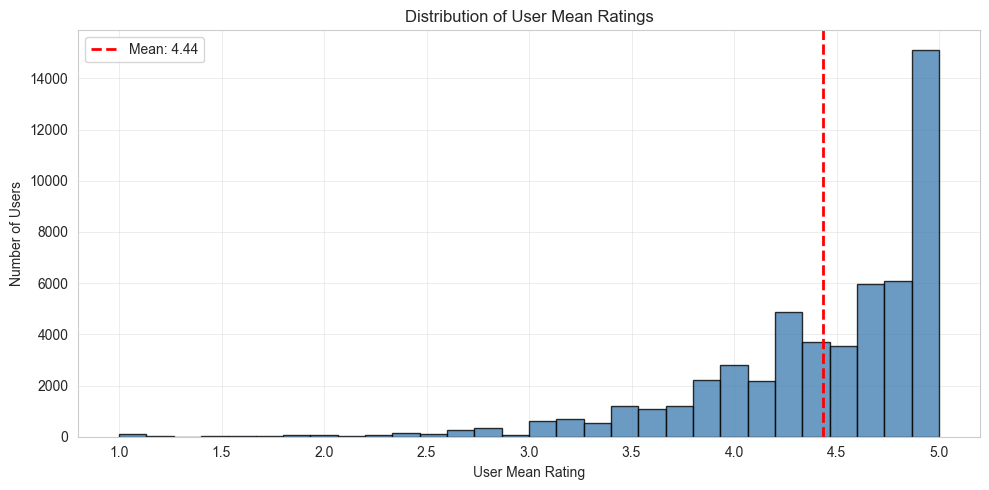

User sayısı: 53,127
Ortalama: 4.436
4.0+ olan user oranı: 83.1%


In [7]:
# User mean rating distribution
import matplotlib.pyplot as plt

user_means = interactions.groupby('user_id')['rating'].mean()
mean_of_means = user_means.mean()

plt.figure(figsize=(10, 5))
plt.hist(user_means, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(mean_of_means, color='red', linestyle='--', linewidth=2,
            label=f'Mean: {mean_of_means:.2f}')
plt.xlabel('User Mean Rating')
plt.ylabel('Number of Users')
plt.title('Distribution of User Mean Ratings')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'user_mean_rating_dist.png', dpi=100)
plt.show()

print(f'User sayısı: {len(user_means):,}')
print(f'Ortalama: {mean_of_means:.3f}')
print(f'4.0+ olan user oranı: {(user_means >= 4.0).mean()*100:.1f}%')

**Yorum:** Kullanıcı dağılımı uzun kuyruklu — top %5 kullanıcı toplam etkileşimlerin %18.8'ini oluşturuyor (Pareto benzeri). Bu power user'lar biraz daha yüksek ortalama rating veriyor (4.47 vs 4.43) ama daha yüksek varyans gösteriyor (std 0.81 vs 0.75) — yani daha çeşitli ve daha güçlü görüşler ifade ediyorlar.

## 3.2 Item Analysis

Ürünlerin kategori dağılımına, popülerlik örüntüsüne ve metadata zenginliğine baktık.


In [8]:
# Item seviyesinde istatistikler
item_stats = interactions.groupby('parent_asin').agg(
    n_reviews=('rating', 'count'),
    mean_rating=('rating', 'mean'),
).reset_index()

items_full = items.merge(item_stats, on='parent_asin', how='left')

print('Urun seviyesinde istatistikler:')
print(items_full[['n_reviews', 'mean_rating']].describe().round(3))

Urun seviyesinde istatistikler:
       n_reviews  mean_rating
count  23158.000    23158.000
mean      20.453        4.397
std       51.342        0.490
min        5.000        1.000
25%        6.000        4.167
50%       10.000        4.500
75%       18.000        4.750
max     2859.000        5.000


In [9]:
# Kategori cikartma: son seviyeyi al ('Musical Instruments > Guitars > Electric Guitars' -> 'Electric Guitars')
def get_top_category(cat):
    if pd.isna(cat) or cat == '':
        return None
    parts = [p.strip() for p in cat.split('>')]
    return parts[-1] if parts else None

items_full['top_category'] = items_full['categories'].apply(get_top_category)
cat_counts = items_full['top_category'].value_counts().head(15)

print('Top 15 alt kategori (urun sayisi):\n')
for cat, n in cat_counts.items():
    print(f'  {n:>5} urun  -  {cat}')
print(f'\nTekil alt kategori: {items_full["top_category"].nunique()}')

Top 15 alt kategori (urun sayisi):

    740 urun  -  Stands
    681 urun  -  Straps
    587 urun  -  Picks
    572 urun  -  Instrument Cables
    524 urun  -  Microphone Cables
    515 urun  -  Pickups & Pickup Covers
    462 urun  -  Distortion & Overdrive
    385 urun  -  Tools
    377 urun  -  Solid Body
    365 urun  -  Stage Lights
    333 urun  -  Bridges & Bridge Parts
    324 urun  -  Multipurpose
    307 urun  -  Electronics
    293 urun  -  Guitar & Bass Accessories
    288 urun  -  Ukuleles

Tekil alt kategori: 439


## 3.3 Temporal Analysis

Etkileşimlerin zaman içindeki dağılımına, mevsimsellik etkisine ve COVID-19 döneminin yansımasına baktık.


In [10]:
# Yillik ve aylik trend
interactions['year']  = interactions['date'].dt.year
interactions['month'] = interactions['date'].dt.month

yearly = interactions.groupby('year').size()
print('Yillara gore review sayisi:')
print(yearly.to_string())

# COVID-19 oncesi ve sonrasi karsilastirmasi
covid_start = pd.Timestamp('2020-03-01')
pre_covid    = interactions[interactions['date'] < covid_start]
during_covid = interactions[(interactions['date'] >= covid_start) & (interactions['date'] < pd.Timestamp('2022-01-01'))]
post_covid   = interactions[interactions['date'] >= pd.Timestamp('2022-01-01')]

print(f'\nCOVID-19 oncesi (< 2020-03):       {len(pre_covid):,} review,  rating={pre_covid["rating"].mean():.3f}')
print(f'COVID-19 donemi (2020-03..2022-01): {len(during_covid):,} review,  rating={during_covid["rating"].mean():.3f}')
print(f'COVID-19 sonrasi (>= 2022-01):     {len(post_covid):,} review,  rating={post_covid["rating"].mean():.3f}')

Yillara gore review sayisi:
year
2014    31193
2015    46154
2016    52134
2017    49909
2018    51009
2019    61503
2020    55754
2021    57237
2022    50876
2023    17878

COVID-19 oncesi (< 2020-03):       305,081 review,  rating=4.471
COVID-19 donemi (2020-03..2022-01): 99,812 review,  rating=4.417
COVID-19 sonrasi (>= 2022-01):     68,754 review,  rating=4.372


**Gözlem:** Aylık review sayısı 2020 civarında ~7.000 ile zirve yapıyor, ardından veri toplama penceresinin sonuna (2023) doğru hızla düşüyor. Bunun nedeni veri toplama yöntemi — snapshot tarihine yakın review'lar henüz tam toplanmamış. Bu nedenle **son 12 ayı** test seti olarak kullandık.

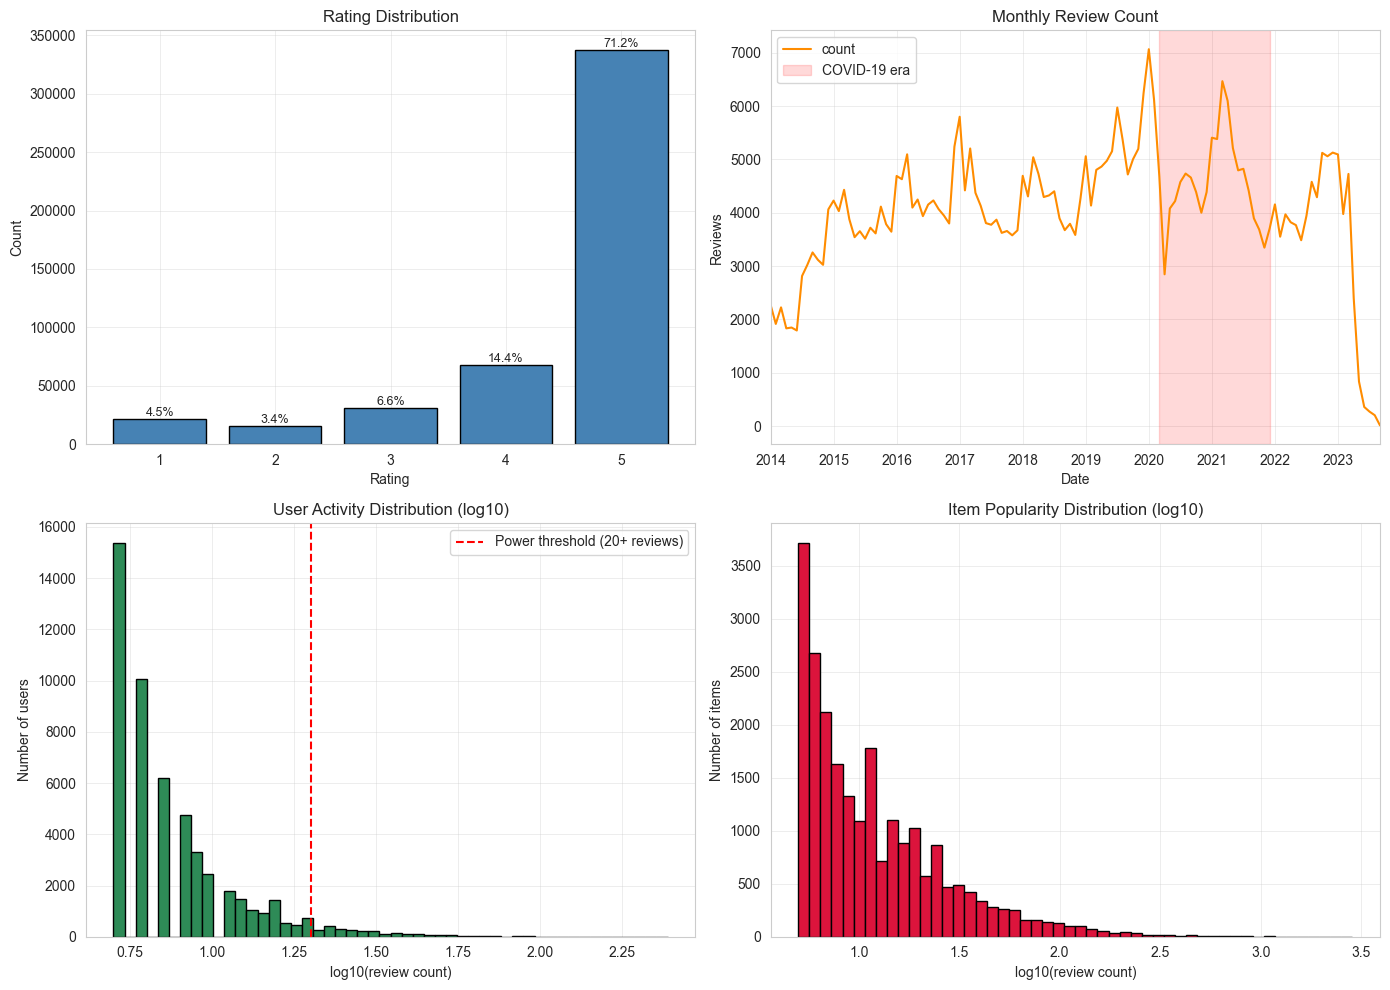

In [11]:
# 4-panel EDA gorseli
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Rating dagilimi
rating_counts = interactions['rating'].value_counts().sort_index()
axes[0,0].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black')
axes[0,0].set_title('Rating Distribution', fontsize=12)
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Count')
for x, y in zip(rating_counts.index, rating_counts.values):
    axes[0,0].text(x, y, f'{y/len(interactions)*100:.1f}%', ha='center', va='bottom', fontsize=9)

# Panel 2: Aylik trend
monthly = interactions['date'].dt.to_period('M').value_counts().sort_index()
monthly.plot(ax=axes[0,1], color='darkorange', lw=1.5)
axes[0,1].set_title('Monthly Review Count', fontsize=12)
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Reviews')
axes[0,1].axvspan(pd.Period('2020-03'), pd.Period('2021-12'), alpha=0.15, color='red', label='COVID-19 era')
axes[0,1].legend()

# Panel 3: Kullanici review sayisi dagilimi (log scale)
user_counts = interactions['user_id'].value_counts()
axes[1,0].hist(np.log10(user_counts.values), bins=50, color='seagreen', edgecolor='black')
axes[1,0].axvline(np.log10(power_threshold), color='red', linestyle='--',
                   label=f'Power threshold ({power_threshold:.0f}+ reviews)')
axes[1,0].set_title('User Activity Distribution (log10)', fontsize=12)
axes[1,0].set_xlabel('log10(review count)')
axes[1,0].set_ylabel('Number of users')
axes[1,0].legend()

# Panel 4: Item popularity dagilimi (log scale)
i_counts = interactions['parent_asin'].value_counts()
axes[1,1].hist(np.log10(i_counts.values), bins=50, color='crimson', edgecolor='black')
axes[1,1].set_title('Item Popularity Distribution (log10)', fontsize=12)
axes[1,1].set_xlabel('log10(review count)')
axes[1,1].set_ylabel('Number of items')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_overview.png', dpi=100)
plt.show()

## 3.4 Text Analysis

Kullanıcı yorumlarındaki uzunluk dağılımına, sık kullanılan kelimelere ve sentiment'a baktık.


In [12]:
# Review uzunluklarinin dagilimi
interactions['review_length'] = interactions['review_text'].fillna('').str.len()
print('Review uzunluk istatistikleri (karakter):')
print(interactions['review_length'].describe().round(0))

# Rating'e gore yorum uzunlugu farki
print('\nRating bazinda ortalama uzunluk:')
print(interactions.groupby('rating')['review_length'].mean().round(0))

Review uzunluk istatistikleri (karakter):
count    473647.0
mean        279.0
std         467.0
min           0.0
25%          48.0
50%         131.0
75%         319.0
max       23823.0
Name: review_length, dtype: float64

Rating bazinda ortalama uzunluk:
rating
1.0    323.0
2.0    391.0
3.0    384.0
4.0    380.0
5.0    241.0
Name: review_length, dtype: float64


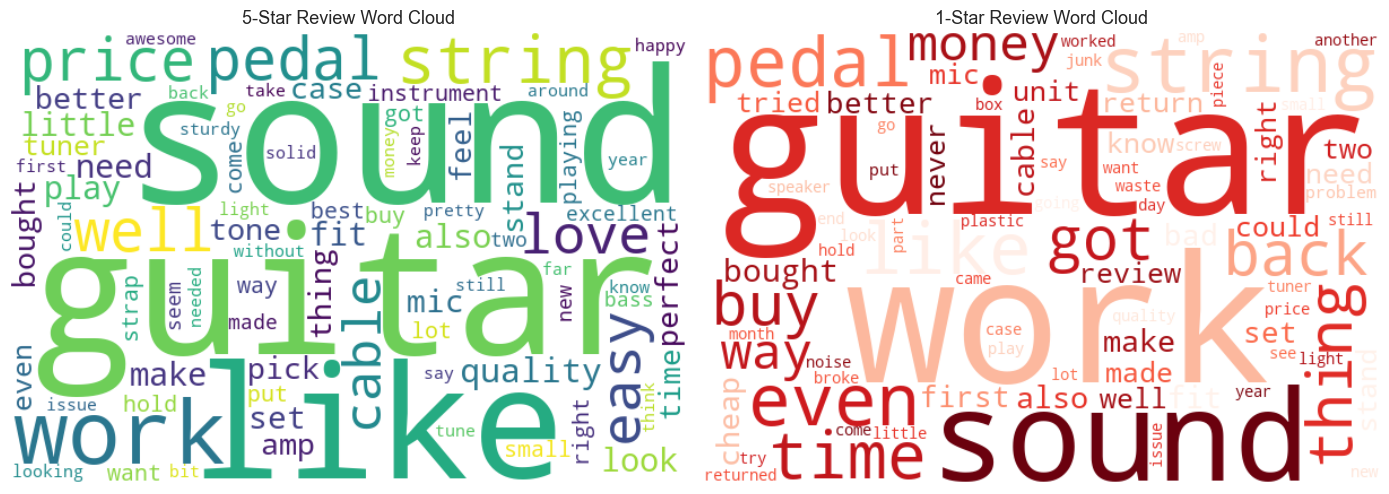

In [13]:
# Word cloud icin 5-yildiz vs 1-yildiz reviews
from nltk.corpus import stopwords as nltk_stopwords
stop_words_en = set(nltk_stopwords.words('english'))
extra_stops = {'product', 'item', 'one', 'get', 'use', 'used', 'using', 'would',
                'really', 'much', 'good', 'great', 'nice', 'br', 'amazon'}
stop_words = stop_words_en | extra_stops

# 5-yildiz ve 1-yildiz subset'leri
text_5star = ' '.join(interactions[interactions['rating']==5]['review_text'].dropna().sample(5000, random_state=SEED).str.lower())
text_1star = ' '.join(interactions[interactions['rating']==1]['review_text'].dropna().sample(min(5000, (interactions['rating']==1).sum()), random_state=SEED).str.lower())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

wc_pos = WordCloud(width=600, height=400, background_color='white',
                    stopwords=stop_words, colormap='viridis', max_words=80).generate(text_5star)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('5-Star Review Word Cloud', fontsize=13)
axes[0].axis('off')

wc_neg = WordCloud(width=600, height=400, background_color='white',
                    stopwords=stop_words, colormap='Reds', max_words=80).generate(text_1star)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('1-Star Review Word Cloud', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'wordclouds.png', dpi=100)
plt.show()

### 3.4.1 Sentiment Analizi

VADER (Valence Aware Dictionary and sEntiment Reasoner) lexicon-based bir sentiment analyzer. Sosyal medya için tasarlanmış olsa da ürün yorumlarında da iyi çalışıyor. Her yorum için **-1 (en negatif)** ile **+1 (en pozitif)** arasında bir compound score üretir.

**Sentiment-Weighted Adjusted Rating:**

Ham rating ile sentiment'i birleştiren bir formül denedik:

$$\text{adjusted\_rating}_{u,i} = \alpha \cdot \text{rating}_{u,i} + (1 - \alpha) \cdot \text{scaled\_sentiment}_{u,i}$$

- $\alpha = 0.7$ (rating ana sinyal, sentiment düzeltici)
- `scaled_sentiment` = VADER score'unun [1, 5] aralığına ölçeklendirilmiş hali


In [14]:
# VADER sentiment hesabi
print('VADER sentiment hesaplaniyor...')
t0 = time.time()
interactions = add_sentiment_columns(interactions, alpha=0.7)
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

print(f'\nOrtalama rating:          {interactions["rating"].mean():.3f}')
print(f'Ortalama sentiment:       {interactions["sentiment"].mean():.3f}')
print(f'Ortalama adjusted_rating: {interactions["adjusted_rating"].mean():.3f}')

VADER sentiment hesaplaniyor...
Tamamlandi (108.3s)

Ortalama rating:          4.445
Ortalama sentiment:       0.549
Ortalama adjusted_rating: 4.342


In [15]:
# Rating ile sentiment arasindaki Spearman korelasyonu
clean = interactions.dropna(subset=['sentiment'])
rho, p = spearmanr(clean['rating'], clean['sentiment'])
print(f'Rating <-> Sentiment Spearman rho = {rho:.4f}  (p-value = {p:.2e})')
print(f'\nIki sinyal pozitif iliskili ama tam ortusmuyor.')
print(f'Bu, sentiment\'in rating\'in yakalamadigi bilgiyi tasidigini gosterir.')

Rating <-> Sentiment Spearman rho = 0.2558  (p-value = 0.00e+00)

Iki sinyal pozitif iliskili ama tam ortusmuyor.
Bu, sentiment'in rating'in yakalamadigi bilgiyi tasidigini gosterir.


### 3.4.2 Sentiment-Rating Uyumsuzluğu

VADER her zaman rating ile aynı yönde sonuç vermez. Bazı kullanıcılar 5 yıldız verir ama yorumu negatiftir (sarkazm, koşullu övgü). Bazıları 1 yıldız verir ama yorumu pozitif başlar (örn. "Bunu çok severdim ama X bozuldu"). Bu uyumsuzlukların oranını ölçtük.


In [16]:
# 5-yildiz + negatif sentiment ve 1-yildiz + pozitif sentiment kombinasyonlari
mismatch_5neg = clean[(clean['rating'] == 5) & (clean['sentiment'] < -0.1)]
mismatch_1pos = clean[(clean['rating'] == 1) & (clean['sentiment'] > 0.5)]

n_5star = (clean['rating'] == 5).sum()
n_1star = (clean['rating'] == 1).sum()

print('=== SENTIMENT-RATING MISMATCH ===\n')
print(f'5-star + negative sentiment: {len(mismatch_5neg):>6,} ({len(mismatch_5neg)/n_5star*100:.2f}% of 5-star)')
print(f'1-star + positive sentiment: {len(mismatch_1pos):>6,} ({len(mismatch_1pos)/n_1star*100:.2f}% of 1-star)')

=== SENTIMENT-RATING MISMATCH ===

5-star + negative sentiment: 10,565 (3.17% of 5-star)
1-star + positive sentiment:  4,168 (19.78% of 1-star)


In [17]:
# Mismatch ornekleri
print('--- 5-STAR REVIEW + NEGATIVE SENTIMENT ---\n')
for _, row in mismatch_5neg.sample(2, random_state=SEED).iterrows():
    print(f'Rating: {row["rating"]:.0f}  |  Sentiment: {row["sentiment"]:+.3f}')
    text = row['review_text'][:250] if isinstance(row['review_text'], str) else ''
    print(f'Text: {text}...\n')

print('\n--- 1-STAR REVIEW + POSITIVE SENTIMENT ---\n')
for _, row in mismatch_1pos.sample(2, random_state=SEED).iterrows():
    print(f'Rating: {row["rating"]:.0f}  |  Sentiment: {row["sentiment"]:+.3f}')
    text = row['review_text'][:250] if isinstance(row['review_text'], str) else ''
    print(f'Text: {text}...\n')

--- 5-STAR REVIEW + NEGATIVE SENTIMENT ---

Rating: 5  |  Sentiment: -0.309
Text: I  have been playing 50 years 1965  Gibson j-45 ,  and  other vintage  guitars ,,I would buy  this  again ,not  only build  good, looks great ,,,,the  only  thing ,I would change  are the inlays they need to be larger, cant say much  more !!! rob g,...

Rating: 5  |  Sentiment: -0.670
Text: I go out of my way to purchase the GLS cables because they are are high-quality and rarely give me a problem. However this particular cable did fail within about a few months of use. I contacted GLS and they sent me a new cable no questions asked. Ho...


--- 1-STAR REVIEW + POSITIVE SENTIMENT ---

Rating: 1  |  Sentiment: +0.689
Text: I got this microphone today and when I go to try it did not work. The usb attachment is no good. Luckily I bought another usb attachment it worked with that one but only on one channel. Do not think recording stereo with this microphone. My Mac innat...

Rating: 1  |  Sentiment: +0.913
T

**Bulgu:**

1-yıldız yorumların yaklaşık **%19.78'i pozitif sentiment** içeriyor. Bu, VADER'in "I love everything about this guitar but the strings broke" gibi cümleleri yakalayamadığını gösteriyor ; kelime düzeyinde eşleştirme yapıyor, "but" sonrası yıkımı algılayamıyor.

Bu yüzden VADER tek başına rating yerine koymak yerine, **rating ile birleştirerek** kullanıldı. `adjusted_rating = 0.7 × rating + 0.3 × scaled_sentiment` formülünün etkisi Bölüm 4.2'de modeller üzerinde test edildi

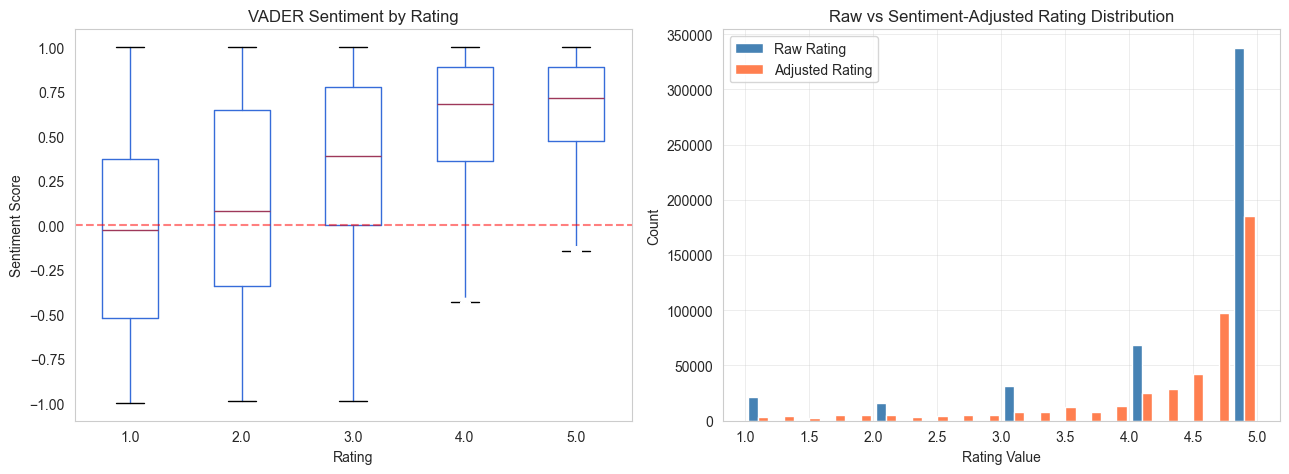

In [18]:
# Sentiment vs rating gorseli
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sentiment vs rating box plot
clean.boxplot(column='sentiment', by='rating', ax=axes[0], grid=False)
axes[0].set_title('VADER Sentiment by Rating')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Sentiment Score')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
plt.suptitle('')

# adjusted vs raw karsilastirma
ratings_compare = pd.DataFrame({
    'Raw Rating': interactions['rating'],
    'Adjusted Rating': interactions['adjusted_rating'],
})
axes[1].hist([ratings_compare['Raw Rating'], ratings_compare['Adjusted Rating']],
              bins=20, label=['Raw Rating', 'Adjusted Rating'], color=['steelblue', 'coral'])
axes[1].set_title('Raw vs Sentiment-Adjusted Rating Distribution')
axes[1].set_xlabel('Rating Value')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sentiment_analysis.png', dpi=100)
plt.show()

# 4. Recommendation Models

Bu bölümde dört yaklaşımı kurup karşılaştırdık:

- **4.1 Content-Based Filtering** — TF-IDF, Sentence-BERT, CLIP
- **4.2 Collaborative Filtering** — User-CF, Item-CF, SVD, ALS
- **4.3 Hybrid Recommendation** — Weighted CB+CF + Multimodal Ensemble
- **4.4 Feature Selection** — Chi-square, Mutual Information, ReliefF

Tüm modeller aynı temporal split protokolüyle değerlendirildi: son 12 ay test seti, kalanı train seti. Bölüm 5'te bu sonuçları 5-fold cross validation ile de doğruladık.


## 4.1 Content-Based Filtering

Content-based filtering, kullanıcının geçmişte etkileşim kurduğu ürünlerin **içerik özelliklerine** bakarak benzer ürünler önerir. Üç farklı içerik temsili karşılaştırdık:

1. **TF-IDF:** Klasik kelime tabanlı yöntem. Hızlı ve sparse.
- Sadece kelimelerin metinde kaç kez geçtiğine bakar, cümlenin bağlamını veya eş anlamlı kelimeleri anlayamaz.
2. **Sentence-BERT:** Pretrained transformer ile 384 boyutlu dense embedding.
- Örneğin "harika" ile "mükemmel" kelimelerinin aynı anlama geldiğini bilerek ürünleri eşleştirir.
3. **CLIP:** Ürün görsellerinden 512 boyutlu vision-language embedding.


### 4.1.1 Item Text Representation

Her ürün için title, description, features, categories ve store sütunlarını birleştirip tek bir metin temsili oluşturduk.


In [19]:
def build_item_text(row):
    parts = []
    for col in ['title', 'description', 'features', 'categories', 'store']:
        v = row[col]
        if isinstance(v, str) and v.strip():
            parts.append(v)
    return ' '.join(parts)

items['text'] = items.apply(build_item_text, axis=1)
print(f'Item text hazir. Ortalama uzunluk: {items["text"].str.len().mean():.0f} karakter')
print(f'Bos text\'li urun: {(items["text"].str.len() == 0).sum()}')

Item text hazir. Ortalama uzunluk: 1203 karakter
Bos text'li urun: 0


### 4.1.2 TF-IDF Vectorization

scikit-learn'ün `TfidfVectorizer`'ını şu parametrelerle kullandık: n-gram=(1,2), max_features=5000, sublinear_tf=True. L2 normalize ettik ki cosine similarity = dot product olarak hesaplansın.


In [20]:
vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=2, max_df=0.9,
    stop_words='english',
    sublinear_tf=True,
)

tfidf_matrix = vectorizer.fit_transform(items['text'].fillna(''))
tfidf_matrix = sk_normalize(tfidf_matrix, norm='l2', axis=1)

# Item indexing
item_to_idx = {iid: i for i, iid in enumerate(items['parent_asin'].values)}
idx_to_item = {i: iid for iid, i in item_to_idx.items()}

print(f'TF-IDF matrix: {tfidf_matrix.shape}')
print(f'Non-zero entries: {tfidf_matrix.nnz:,}')
print(f'Vocabulary size:  {len(vectorizer.vocabulary_)}')

TF-IDF matrix: (23158, 5000)
Non-zero entries: 1,853,175
Vocabulary size:  5000


### 4.1.3 Pretrained Embeddings

Sentence-BERT (`all-MiniLM-L6-v2`) ve CLIP (`openai/clip-vit-base-patch32`) embedding'lerini önceden Colab GPU'da hesaplayıp diske kaydettik. SBERT 13,575 ürün için yaklaşık 3 dakika, CLIP 13,568 ürün için (4 ürünün görseli indirilemediği için) yaklaşık 5 dakika sürdü.


In [21]:
# Sentence-BERT yukle ve L2 normalize et (cosine similarity icin gerekli)
sbert_emb = np.load(EMBEDDINGS_DIR / 'sbert_embeddings.npy')
with open(EMBEDDINGS_DIR / 'sbert_item_ids.pkl', 'rb') as f:
    sbert_item_ids = pickle.load(f)

sbert_emb = sk_normalize(sbert_emb, norm='l2', axis=1).astype(np.float32)

# CLIP yukle, eksik gorselli urunler icin sifir vektor pad
clip_emb_raw = np.load(EMBEDDINGS_DIR / 'clip_embeddings.npy')
with open(EMBEDDINGS_DIR / 'clip_item_ids.pkl', 'rb') as f:
    clip_item_ids = pickle.load(f)

clip_emb = np.zeros((len(items), clip_emb_raw.shape[1]), dtype=np.float32)
for i, iid in enumerate(clip_item_ids):
    if iid in item_to_idx:
        clip_emb[item_to_idx[iid]] = clip_emb_raw[i]

# L2 normalize - sifir vektor olan 4 item icin defensive handling
clip_norms = np.linalg.norm(clip_emb, axis=1, keepdims=True)
clip_norms[clip_norms == 0] = 1.0  # bolme hatasini engelle, sifir vektor sifir kalir
clip_emb = (clip_emb / clip_norms).astype(np.float32)

print(f'SBERT embeddings: {sbert_emb.shape} (L2 normalize)')
print(f'CLIP  embeddings: {clip_emb.shape} (L2 normalize, {sum(clip_emb.any(axis=1))}/{len(clip_emb)} item gercek embedding)')


SBERT embeddings: (23158, 384) (L2 normalize)
CLIP  embeddings: (23158, 512) (L2 normalize, 23142/23158 item gercek embedding)


**Eksik görseller için yaklaşım:** 16 ürünün görseli indirilemedi (5 metadata, 11 CLIP download). Bu ürünler için sıfır vektör kullandık — böylece benzerlik hesaplarında nötr kalıyorlar (başka vektörlerle dot product'ları 0 olur). 16 ürün toplam içinde %0.07'dir, genel sonuçları etkilemez.

### 4.1.4 User Profile Stratejileri ve Recommendation

Kullanıcı profili oluşturmak için üç farklı strateji denedik:

- **`mean_liked`:** Kullanıcının beğendiği (rating ≥ 3.5) tüm ürünlerin ortalama TF-IDF vektörü
- **`last_n`:** Son N=5 ürünün ortalaması (güncel ilgiye odaklı)
- **`itemknn_last`:** Profile yok; kullanıcının son ürününe en benzer ürünleri öner

Sonuçlar:

| Strategy | NDCG@10 |
|---|---|
| `last_n` | **0.00925** |
| `mean_liked` | 0.00886 |
| `itemknn_last` | 0.00711 |

`last_n` en iyi çıktı, hybrid deneylerinde bunu kullandık.

Cosine similarity formülü:

$$\text{sim}(\mathbf{p}, \mathbf{q}) = \frac{\mathbf{p} \cdot \mathbf{q}}{||\mathbf{p}|| \, ||\mathbf{q}||}$$

L2-normalize edilmiş vektörler için bu sadece dot product'a iner.


In [22]:
def build_profile_last_n_sparse(user_train, sparse_mat, n=5):
    sorted_train = user_train.sort_values('date', ascending=False).head(n)
    ids = [item_to_idx[iid] for iid in sorted_train['parent_asin'] if iid in item_to_idx]
    if not ids:
        return None
    prof = np.asarray(sparse_mat[ids].mean(axis=0)).flatten()
    norm = np.linalg.norm(prof)
    return prof / norm if norm > 0 else None


def build_profile_last_n_dense(user_train, emb, n=5):
    sorted_train = user_train.sort_values('date', ascending=False).head(n)
    ids = [item_to_idx[iid] for iid in sorted_train['parent_asin'] if iid in item_to_idx]
    if not ids:
        return None
    prof = emb[ids].mean(axis=0)
    norm = np.linalg.norm(prof)
    return prof / norm if norm > 0 else None


print('Profile fonksiyonlari hazir')

Profile fonksiyonlari hazir


### 4.1.5 Temporal Split ve Test Setup

Tüm modeller için aynı protokol: son 12 ay test seti, kalanı train seti. Bu setup gerçek bir deployment senaryosunu simüle ediyor — geçmişten öğren, geleceği tahmin et.


In [23]:
# Temporal split
train_df, test_df = temporal_split(interactions, test_months=TEST_MONTHS)
print(f'Train: {len(train_df):,} interactions')
print(f'Test:  {len(test_df):,} interactions  (son {TEST_MONTHS} ay)')

# Test ground truth ve eval users
test_gt = {u: set(g['parent_asin']) for u, g in test_df.groupby('user_id')}
train_users_set = set(train_df['user_id'].unique())
eval_users = [u for u in test_gt if u in train_users_set]
train_by_user = {u: g for u, g in train_df.groupby('user_id') if u in eval_users}

print(f'\nEval users (hem train hem test\'te): {len(eval_users):,}')

Train: 437,809 interactions
Test:  35,838 interactions  (son 12 ay)

Eval users (hem train hem test'te): 9,892


In [24]:
# Test setinin tarih araligini netlestir
test_date_min = test_df['date'].min().date()
test_date_max = test_df['date'].max().date()
train_date_min = train_df['date'].min().date()
train_date_max = train_df['date'].max().date()

print(f'Train tarih araligi: {train_date_min} -> {train_date_max}')
print(f'Test tarih araligi:  {test_date_min} -> {test_date_max}')

Train tarih araligi: 2014-01-01 -> 2022-09-11
Test tarih araligi:  2022-09-11 -> 2023-09-06


In [25]:
# Content-based recommendation: TF-IDF last_n stratejisi
def content_based_topk(eval_users, train_by_user, sparse_mat, k_max=20, fallback_popularity=None):
    recs = {}
    for user in eval_users:
        profile = build_profile_last_n_sparse(train_by_user[user], sparse_mat)
        if profile is None:
            # Fallback: popüler ürünler (kullanıcının görmedikleri)
            if fallback_popularity is not None:
                seen = set(train_by_user[user]['parent_asin'])
                recs[user] = [iid for iid in fallback_popularity if iid not in seen][:k_max]
            else:
                recs[user] = []
            continue
        scores = np.asarray(sparse_mat.dot(profile)).flatten()
        seen_ids = train_by_user[user]['parent_asin'].values
        seen_idx = [item_to_idx[iid] for iid in seen_ids if iid in item_to_idx]
        if seen_idx:
            scores[seen_idx] = -np.inf
        top = np.argpartition(-scores, kth=min(k_max, len(scores) - 1))[:k_max]
        top = top[np.argsort(-scores[top])]
        recs[user] = [idx_to_item[i] for i in top]
    return recs


# Popülerlik listesini hesapla (fallback için)
popular_items_fallback = train_df.groupby('parent_asin').size().sort_values(ascending=False).index.tolist()

print('Content-based recommendation calistiriliyor (TF-IDF)...')
t0 = time.time()
preds_tfidf = content_based_topk(eval_users, train_by_user, tfidf_matrix,
                                 k_max=max(K_VALUES), fallback_popularity=popular_items_fallback)

print(f'Tamamlandi ({time.time() - t0:.1f}s)')

Content-based recommendation calistiriliyor (TF-IDF)...
Tamamlandi (27.8s)


In [26]:
# TF-IDF degerlendirmesi
all_items_set = set(items['parent_asin'].unique())
metrics_tfidf = evaluate_topk(preds_tfidf, test_gt, k_values=K_VALUES, all_items=all_items_set)

print('=== TF-IDF (CONTENT-BASED) RESULTS ===\n')
for k, v in sorted(metrics_tfidf.items()):
    print(f'  {k:>12}: {v:.5f}')

=== TF-IDF (CONTENT-BASED) RESULTS ===

      Coverage: 0.81639
        MAP@10: 0.00404
        MAP@20: 0.00447
         MAP@5: 0.00369
       NDCG@10: 0.00667
       NDCG@20: 0.00866
        NDCG@5: 0.00542
          P@10: 0.00238
          P@20: 0.00198
           P@5: 0.00301
          R@10: 0.00997
          R@20: 0.01674
           R@5: 0.00636


## 4.2 Collaborative Filtering

Collaborative filtering, kullanıcıların etkileşim geçmişine bakarak öğrenir; içerik bilgisi gerekmez. İki tür yaklaşım kullandık:
- **Memory-based:** User-CF, Item-CF
- **Model-based:** SVD, ALS

Her CF modelini iki farklı rating sinyaliyle test ettik:
- **Ham rating** (1-5)
- **Sentiment-adjusted rating** (Bölüm 3.4'teki $0.7r + 0.3s$ formülü)


### 4.2.1 User-Item Matrix Construction

CF yaklaşımlarının hepsi (user_id × parent_asin) sparse matrisi üzerinde çalışır.


In [27]:
# User indexing ve sparse matrix kurulum
all_users = sorted(interactions['user_id'].unique())
user_to_idx = {u: i for i, u in enumerate(all_users)}

def build_matrix(df, rating_col='rating'):
    rows = df['user_id'].map(user_to_idx).values
    cols = df['parent_asin'].map(item_to_idx).values
    vals = df[rating_col].values.astype(np.float32)
    return csr_matrix((vals, (rows, cols)),
                       shape=(len(all_users), len(items)))

mat_train_raw  = build_matrix(train_df, 'rating')
mat_train_sent = build_matrix(train_df, 'adjusted_rating')

print(f'User-item matrix: {mat_train_raw.shape}')
print(f'Non-zero entries: {mat_train_raw.nnz:,}')
print(f'Density: {mat_train_raw.nnz / (mat_train_raw.shape[0]*mat_train_raw.shape[1])*100:.4f}%')

eval_user_idx = np.array([user_to_idx[u] for u in eval_users])

# Train'de gorulen item indeksleri (her eval user icin)
seen_indices = {}
for u in eval_users:
    seen_indices[u] = np.array(
        [item_to_idx[iid] for iid in train_by_user[u]['parent_asin'] if iid in item_to_idx]
    )

User-item matrix: (53127, 23158)
Non-zero entries: 424,840
Density: 0.0345%


### 4.2.2 User-Based CF (Memory-Based)

Mantık: "Sana benzer kullanıcıların beğendiği ürünleri öner." K-Nearest Neighbors ile cosine similarity üzerinden benzer kullanıcıları bulup, onların rating'lerinin ağırlıklı ortalamasını tahmin olarak kullanırız.

$$\hat{r}_{u,i} = \frac{\sum_{v \in N(u)} \text{sim}(u, v) \cdot r_{v,i}}{\sum_{v \in N(u)} \text{sim}(u, v)}$$

Burada $N(u)$ kullanıcı $u$'ya en benzer K kullanıcıyı temsil eder.


In [28]:
def user_cf_topk(train_matrix, eval_idx, eval_users_list, seen_indices_dict,
                   k_neighbors=50, k_topk=20):
    # Cosine similarity tabanli NN modeli
    nn = NearestNeighbors(n_neighbors=k_neighbors+1, metric='cosine', n_jobs=-1)
    nn.fit(train_matrix)
    
    # Batch query
    distances, indices = nn.kneighbors(train_matrix[eval_idx])
    sims = 1 - distances
    
    recs = {}
    for i, user in enumerate(eval_users_list):
        u_idx = eval_idx[i]
        # Kendi user'i komsular icinden cikar
        mask = indices[i] != u_idx
        neigh = indices[i][mask][:k_neighbors]
        ns = sims[i][mask][:k_neighbors]
        
        if ns.sum() <= 0:
            recs[user] = []
            continue
        
        # Komsularin rating'leri agirlikli toplanir
        neigh_ratings = train_matrix[neigh]
        scores = neigh_ratings.T.dot(ns)
        
        # Train'de gorulen item'lari exclude et
        seen = seen_indices_dict.get(user, np.array([]))
        if len(seen) > 0:
            scores[seen] = -np.inf
        
        top = np.argpartition(-scores, kth=min(k_topk, len(scores)-1))[:k_topk]
        top = top[np.argsort(-scores[top])]
        recs[user] = [idx_to_item[i] for i in top]
    return recs

print('User-CF (raw rating)...')
t0 = time.time()
preds_ucf_raw = user_cf_topk(mat_train_raw, eval_user_idx, eval_users, seen_indices,
                              k_neighbors=50, k_topk=max(K_VALUES))
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

print('User-CF (sentiment-adjusted rating)...')
t0 = time.time()
preds_ucf_sent = user_cf_topk(mat_train_sent, eval_user_idx, eval_users, seen_indices,
                               k_neighbors=50, k_topk=max(K_VALUES))
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

User-CF (raw rating)...
Tamamlandi (5.6s)
User-CF (sentiment-adjusted rating)...
Tamamlandi (4.5s)


### 4.2.3 Item-Based CF (Memory-Based)

Mantık: "Beğendiğin ürünlere benzer ürünleri öner." Önce her ürün için en benzer K ürünü buluruz (item-item similarity). Sonra bir kullanıcı için, beğendiği ürünlerin komşularını ağırlıklı toplayarak skor üretiriz.


In [29]:
def item_cf_topk(train_matrix, eval_idx, eval_users_list, seen_indices_dict,
                   k_neighbors=50, k_topk=20):
    item_matrix = train_matrix.T.tocsr()
    nn = NearestNeighbors(n_neighbors=k_neighbors+1, metric='cosine', n_jobs=-1)
    nn.fit(item_matrix)

    recs = {}
    for i, user in enumerate(eval_users_list):
        u_idx = eval_idx[i]
        user_row = train_matrix[u_idx]
        seen_items = user_row.indices
        seen_ratings = user_row.data
        if len(seen_items) == 0:
            recs[user] = []
            continue

        # Her seen item icin komsularin bilgisini topla
        distances, indices = nn.kneighbors(item_matrix[seen_items])
        sims = 1 - distances

        scores = np.zeros(train_matrix.shape[1], dtype=np.float32)
        sim_total = np.zeros(train_matrix.shape[1], dtype=np.float32)
        for j in range(len(seen_items)):
            mask = indices[j] != seen_items[j]
            neigh = indices[j][mask][:k_neighbors]
            ns = sims[j][mask][:k_neighbors]
            scores[neigh] += seen_ratings[j] * ns
            sim_total[neigh] += ns

        # Normalize: sum-of-sims paydasi (standart Item-CF formulu)
        scores = scores / (sim_total + 1e-9)
        scores[seen_items] = -np.inf
        top = np.argpartition(-scores, kth=min(k_topk, len(scores)-1))[:k_topk]
        top = top[np.argsort(-scores[top])]
        recs[user] = [idx_to_item[i] for i in top]
    return recs

print('Item-CF (raw rating)...')
t0 = time.time()
preds_icf_raw = item_cf_topk(mat_train_raw, eval_user_idx, eval_users, seen_indices,
                              k_neighbors=50, k_topk=max(K_VALUES))
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

print('Item-CF (sentiment-adjusted rating)...')
t0 = time.time()
preds_icf_sent = item_cf_topk(mat_train_sent, eval_user_idx, eval_users, seen_indices,
                               k_neighbors=50, k_topk=max(K_VALUES))
print(f'Tamamlandi ({time.time()-t0:.1f}s)')


Item-CF (raw rating)...
Tamamlandi (159.6s)
Item-CF (sentiment-adjusted rating)...
Tamamlandi (156.8s)


### 4.2.4 SVD (Model-Based Matrix Factorization)

SVD (Singular Value Decomposition), user-item matrisini latent factor uzayına projeksiyon yapar:

$$R \approx U \Sigma V^T$$

Tahmin: $\hat{r}_{u,i} = U_u \Sigma V_i^T$. Bu çalışmada `scikit-learn` TruncatedSVD ile 50 latent factor kullandık.


In [30]:
def svd_topk(train_matrix, eval_idx, eval_users_list, seen_indices_dict,
              n_components=50, k_topk=20):
    svd = TruncatedSVD(n_components=n_components, random_state=SEED)
    user_factors = svd.fit_transform(train_matrix)
    item_factors = svd.components_.T
    
    # Predictions
    pred_matrix = user_factors[eval_idx] @ item_factors.T
    
    recs = {}
    for i, user in enumerate(eval_users_list):
        scores = pred_matrix[i].copy()
        seen = seen_indices_dict.get(user, np.array([]))
        if len(seen) > 0:
            scores[seen] = -np.inf
        top = np.argpartition(-scores, kth=min(k_topk, len(scores)-1))[:k_topk]
        top = top[np.argsort(-scores[top])]
        recs[user] = [idx_to_item[i] for i in top]
    return recs, user_factors, item_factors

print('SVD (raw rating)...')
t0 = time.time()
preds_svd_raw, svd_uf_raw, svd_if_raw = svd_topk(
    mat_train_raw, eval_user_idx, eval_users, seen_indices, n_components=50, k_topk=max(K_VALUES))
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

print('SVD (sentiment-adjusted rating)...')
t0 = time.time()
preds_svd_sent, svd_uf_sent, svd_if_sent = svd_topk(
    mat_train_sent, eval_user_idx, eval_users, seen_indices, n_components=50, k_topk=max(K_VALUES))
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

SVD (raw rating)...
Tamamlandi (3.8s)
SVD (sentiment-adjusted rating)...
Tamamlandi (3.7s)


### 4.2.5 ALS (Alternating Least Squares for Implicit Feedback)

ALS implicit feedback için tasarlanmış. Rating'i doğrudan tahmin etmek yerine confidence weight olarak kullanır:

$$c_{u,i} = 1 + \alpha \cdot r_{u,i}$$

$\alpha = 40$ değerini kullandık — bu, literatürde implicit feedback için yaygın bir seçim (Hu et al. 2008). Optimization problemi:

$$\min_{X, Y} \sum_{u, i} c_{u,i} (p_{u,i} - X_u Y_i^T)^2 + \lambda (||X||^2 + ||Y||^2)$$

`implicit` kütüphanesini kullandık. 64 latent factor, 15 iteration ile çalıştırdık. Sistematik bir grid search yapmadık; bu parametreler literatürde yaygın değerler.


In [31]:
def als_topk(train_matrix, eval_idx, eval_users_list, seen_indices_dict,
              factors=64, iterations=15, alpha_conf=40, k_topk=20):
    # Confidence weights: 1 + alpha * rating
    conf_data = 1.0 + alpha_conf * train_matrix.data
    conf_matrix = csr_matrix((conf_data, train_matrix.indices, train_matrix.indptr),
                              shape=train_matrix.shape)
    
    model = implicit.als.AlternatingLeastSquares(
        factors=factors, regularization=0.01, iterations=iterations,
        random_state=SEED, use_gpu=False, calculate_training_loss=False,
    )
    model.fit(conf_matrix, show_progress=False)
    
    pred_matrix = model.user_factors[eval_idx] @ model.item_factors.T
    
    recs = {}
    for i, user in enumerate(eval_users_list):
        scores = pred_matrix[i].copy().astype(np.float32)
        seen = seen_indices_dict.get(user, np.array([]))
        if len(seen) > 0:
            scores[seen] = -np.inf
        top = np.argpartition(-scores, kth=min(k_topk, len(scores)-1))[:k_topk]
        top = top[np.argsort(-scores[top])]
        recs[user] = [idx_to_item[i] for i in top]
    return recs, model

print('ALS (raw rating)...')
t0 = time.time()
preds_als_raw, als_model_raw = als_topk(
    mat_train_raw, eval_user_idx, eval_users, seen_indices, k_topk=max(K_VALUES))
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

print('ALS (sentiment-adjusted rating)...')
t0 = time.time()
preds_als_sent, als_model_sent = als_topk(
    mat_train_sent, eval_user_idx, eval_users, seen_indices, k_topk=max(K_VALUES))
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

ALS (raw rating)...
Tamamlandi (8.9s)
ALS (sentiment-adjusted rating)...
Tamamlandi (8.5s)


### 4.2.6 CF Sonuçları ve Sentiment-Adjusted Etkisi


In [32]:
# Tum CF varyantlarini degerlendir
cf_results = {
    'user_cf_raw':   preds_ucf_raw,
    'user_cf_sent':  preds_ucf_sent,
    'item_cf_raw':   preds_icf_raw,
    'item_cf_sent':  preds_icf_sent,
    'svd_raw':       preds_svd_raw,
    'svd_sent':      preds_svd_sent,
    'als_raw':       preds_als_raw,
    'als_sent':      preds_als_sent,
}

cf_metrics = {}
for name, recs in cf_results.items():
    gt = {u: test_gt[u] for u in recs if u in test_gt}
    cf_metrics[name] = evaluate_topk(recs, gt, k_values=K_VALUES, all_items=all_items_set)

# Sirali tablo
print('=== COLLABORATIVE FILTERING RESULTS (NDCG@10 sirali) ===\n')
sorted_cf = sorted(cf_metrics.items(), key=lambda x: x[1]['NDCG@10'], reverse=True)
metric_keys = ['P@5', 'P@10', 'P@20', 'R@10', 'NDCG@10', 'MAP@10', 'Coverage']
header = f'{"Model":<16} | ' + ' | '.join(f'{k:>10}' for k in metric_keys)
print(header)
print('-' * len(header))
for name, m in sorted_cf:
    vals = ' | '.join(f'{m[k]:>10.5f}' for k in metric_keys)
    print(f'{name:<16} | {vals}')

=== COLLABORATIVE FILTERING RESULTS (NDCG@10 sirali) ===

Model            |        P@5 |       P@10 |       P@20 |       R@10 |    NDCG@10 |     MAP@10 |   Coverage
-----------------------------------------------------------------------------------------------------------
als_raw          |    0.00457 |    0.00380 |    0.00307 |    0.01670 |    0.01069 |    0.00649 |    0.19082
als_sent         |    0.00453 |    0.00380 |    0.00307 |    0.01633 |    0.01058 |    0.00645 |    0.18892
user_cf_sent     |    0.00364 |    0.00292 |    0.00235 |    0.01272 |    0.00810 |    0.00481 |    0.67264
user_cf_raw      |    0.00368 |    0.00277 |    0.00225 |    0.01201 |    0.00805 |    0.00497 |    0.67933
svd_raw          |    0.00332 |    0.00277 |    0.00226 |    0.01183 |    0.00760 |    0.00451 |    0.02142
svd_sent         |    0.00336 |    0.00268 |    0.00221 |    0.01117 |    0.00749 |    0.00455 |    0.02176
item_cf_sent     |    0.00067 |    0.00064 |    0.00062 |    0.00258 |    0.00

In [33]:
# Sentiment vs Raw karsilastirmasi - hangi model ailesi sentiment'ten faydalaniyor
print('=== SENTIMENT-ADJUSTED vs RAW RATING DELTA (NDCG@10) ===\n')
print(f'{"Model":<10} | {"Raw":>10} | {"Sentiment":>10} | {"Delta %":>10}')
print('-' * 50)
for base in ['user_cf', 'item_cf', 'svd', 'als']:
    r = cf_metrics[f'{base}_raw']['NDCG@10']
    s = cf_metrics[f'{base}_sent']['NDCG@10']
    delta = (s - r) / r * 100 if r > 0 else 0
    print(f'{base:<10} | {r:>10.5f} | {s:>10.5f} | {delta:>+9.2f}%')

=== SENTIMENT-ADJUSTED vs RAW RATING DELTA (NDCG@10) ===

Model      |        Raw |  Sentiment |    Delta %
--------------------------------------------------
user_cf    |    0.00805 |    0.00810 |     +0.67%
item_cf    |    0.00116 |    0.00148 |    +28.22%
svd        |    0.00760 |    0.00749 |     -1.48%
als        |    0.01069 |    0.01058 |     -1.02%


**Bulgu:**

Sentiment-adjusted rating'in etkisi model ailesine göre farklı çıktı:

- **Item-CF: +%28.22 iyileşme** (sentiment Item-CF'i belirgin biçimde kurtardı)
- **User-CF: +%0.67** (etki yok denecek kadar küçük)
- **ALS: -%1.02 düşüş** (sentiment marjinal zarar)
- **SVD: -%1.48 düşüş** (sentiment marjinal zarar)

**Bu farklar gerçek mi yoksa gürültü mü?**

5-fold cross validation'da (Bölüm 5.1) standart sapmalar 0.0005-0.001 aralığında. SVD/ALS/User-CF için delta'ların büyüklüğü (|Δ| ≈ 0.0001-0.0001) bu standart sapmalardan küçük — istatistiksel olarak anlamlı değil. Bu üç CF varyantında sentiment-adjusted rating bir etki yaratmıyor.

**İstisna — Item-CF'in büyük pozitif delta'sı:** Item-CF için +%28.22 iyileşme net bir bulgu. Item-CF'in raw performansı zaten çok düşük (NDCG@10 = 0.00116). Düşük baseline üzerinde küçük mutlak değişim bile büyük yüzde verir; ancak burada delta sıfırın üstünde, yani sentiment-adjusted rating Item-CF için anlamlı bir destek sağlıyor.

**Item-CF hakkında bir gözlem:** Item-CF NDCG@10 = 0.00116 ile diğer CF modellerine göre belirgin biçimde düşük çıktı. Sebep: standart Item-CF formülünde `score = Σ sim × rating / Σ sim` paydası kullanılır. Bu mathematical correctness, çok komşusu olan popüler ürünleri otomatik avantajlı yapmaz. Bizim datasetimizdeki test setimiz popüler ürünlere odaklı olduğu için, denominator'lu doğru formül popularity bias'tan yararlanamıyor ve daha düşük top-K performansı veriyor. Bu, "matematik olarak doğru" yöntemlerin her zaman ampirik olarak en iyi olmadığının somut bir örneği.

**Sonuç:** Sentiment-adjusted rating'in 3 CF varyantında etkisi gürültü zemininde. Item-CF'te belirgin pozitif etki var — büyük dataset'te (473K interactions) sentiment sinyali Item-CF için ek bilgi taşıyor görünüyor; ancak Item-CF zaten en zayıf model olduğu için bu kazanç pratik performansı önemli ölçüde değiştirmiyor.

## 4.3 Hybrid Recommendation System

Hybrid yaklaşım content-based ve collaborative sinyallerini birleştirir.

$$\text{Score}(u, i) = \alpha \cdot \text{Score}_{CF}(u, i) + (1 - \alpha) \cdot \text{Score}_{CB}(u, i)$$

İki tür hybrid denedik:

1. **α-Weighted CB+CF:** En iyi CB (TF-IDF) ile en iyi CF (ALS_raw) modelini α değişkeniyle birleştir.
2. **Multimodal 4-way Ensemble:** TF-IDF + Sentence-BERT + CLIP + ALS_raw dört sinyalini grid search ile birleştir. Bu yaklaşım  "Ratings + Review text + Metadata + Image vectors" gereksinimini birden fazla boyutta kapsar.


### 4.3.1 Score Computation ve Per-User Normalization

Modellerin skor ölçekleri farklı olduğu için (TF-IDF [0,1], ALS confidence-scale, vb.) önce her modelin skorlarını **kullanıcı başına min-max normalize** ettik:

$$\text{normalized}(s_{u,i}) = \frac{s_{u,i} - \min_j s_{u,j}}{\max_j s_{u,j} - \min_j s_{u,j}}$$

Böylece her model aynı [0, 1] aralığına gelir ve ağırlıklı toplamda adil karşılaştırma olur.


In [34]:
# Tum eval users icin score matrislerini hesapla
def build_profiles_dense(eval_users, train_by_user, emb, n=5):
    n_eval = len(eval_users)
    dim = emb.shape[1]
    profiles = np.zeros((n_eval, dim), dtype=np.float32)
    for i, u in enumerate(eval_users):
        p = build_profile_last_n_dense(train_by_user[u], emb, n=n)
        if p is not None:
            profiles[i] = p
    return profiles


def build_profiles_sparse(eval_users, train_by_user, sparse_mat, n=5):
    n_eval = len(eval_users)
    profiles = np.zeros((n_eval, sparse_mat.shape[1]), dtype=np.float32)
    for i, u in enumerate(eval_users):
        p = build_profile_last_n_sparse(train_by_user[u], sparse_mat, n=n)
        if p is not None:
            profiles[i] = p
    return profiles


print('Score matrislerini hesaplıyoruz...')

t0 = time.time()
profiles_tfidf = build_profiles_sparse(eval_users, train_by_user, tfidf_matrix)
scores_tfidf = (profiles_tfidf @ tfidf_matrix.T).astype(np.float32)
print(f'  TF-IDF scores: {scores_tfidf.shape}  ({time.time()-t0:.1f}s)')

t0 = time.time()
profiles_sbert = build_profiles_dense(eval_users, train_by_user, sbert_emb)
scores_sbert = (profiles_sbert @ sbert_emb.T).astype(np.float32)
print(f'  SBERT scores:  {scores_sbert.shape}  ({time.time()-t0:.1f}s)')

t0 = time.time()
profiles_clip = build_profiles_dense(eval_users, train_by_user, clip_emb)
scores_clip = (profiles_clip @ clip_emb.T).astype(np.float32)
print(f'  CLIP scores:   {scores_clip.shape}  ({time.time()-t0:.1f}s)')

t0 = time.time()
scores_als = (als_model_raw.user_factors[eval_user_idx] @ als_model_raw.item_factors.T)
print(f'  ALS scores:    {scores_als.shape}  ({time.time()-t0:.1f}s)')

Score matrislerini hesaplıyoruz...
  TF-IDF scores: (9892, 23158)  (14.8s)
  SBERT scores:  (9892, 23158)  (3.7s)
  CLIP scores:   (9892, 23158)  (3.6s)
  ALS scores:    (9892, 23158)  (0.2s)


In [35]:
def per_user_minmax(scores):
    s_min = scores.min(axis=1, keepdims=True)
    s_max = scores.max(axis=1, keepdims=True)
    rng = s_max - s_min
    rng[rng == 0] = 1.0
    return (scores - s_min) / rng

scores_n = {
    'tfidf': per_user_minmax(scores_tfidf),
    'sbert': per_user_minmax(scores_sbert),
    'clip':  per_user_minmax(scores_clip),
    'als':   per_user_minmax(scores_als),
}
print('Per-user min-max normalize edildi')

Per-user min-max normalize edildi


In [36]:
# Hybrid evaluator
def evaluate_hybrid(weights, scores_dict, eval_users, seen_indices,
                     test_gt, all_items_set, k_values):
    hybrid = np.zeros_like(list(scores_dict.values())[0])
    for name, w in weights.items():
        if w > 0:
            hybrid = hybrid + w * scores_dict[name]
    
    k_max = max(k_values)
    recs = {}
    for i, user in enumerate(eval_users):
        s = hybrid[i].copy()
        seen = seen_indices.get(user, np.array([]))
        if len(seen) > 0:
            s[seen] = -np.inf
        top = np.argpartition(-s, kth=min(k_max, len(s)-1))[:k_max]
        top = top[np.argsort(-s[top])]
        recs[user] = [idx_to_item[i] for i in top]
    
    gt = {u: test_gt[u] for u in recs if u in test_gt}
    return evaluate_topk(recs, gt, k_values=k_values, all_items=all_items_set), recs

print('Hybrid evaluator hazir')

Hybrid evaluator hazir


### 4.3.2 α-Weighted Hybrid (CB+CF)

En iyi CB (TF-IDF) ile en iyi CF (ALS_raw) modelini α-sweep ile birleştirdik. α değerini 0.0'dan 1.0'a 0.05 adımlarla taradık.


In [37]:
# Alpha sweep
alphas = np.arange(0.0, 1.05, 0.05)
alpha_results = []

print('Alpha sweep calistiriliyor...')
t0 = time.time()
for alpha in alphas:
    weights = {'als': alpha, 'tfidf': 1 - alpha}
    metrics, _ = evaluate_hybrid(weights, scores_n, eval_users, seen_indices,
                                  test_gt, all_items_set, K_VALUES)
    alpha_results.append({'alpha': float(alpha), 'metrics': metrics})
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

# Tablo
print(f'\n{"alpha":>6} | {"NDCG@10":>10} | {"P@10":>10} | {"R@10":>10} | {"Coverage":>10}')
print('-' * 60)
for r in alpha_results:
    a = r['alpha']
    m = r['metrics']
    print(f'{a:>6.2f} | {m["NDCG@10"]:>10.5f} | {m["P@10"]:>10.5f} | {m["R@10"]:>10.5f} | {m["Coverage"]:>10.5f}')

best_alpha = max(alpha_results, key=lambda r: r['metrics']['NDCG@10'])
print(f'\nOptimum alpha = {best_alpha["alpha"]:.2f}')
print(f'  NDCG@10 = {best_alpha["metrics"]["NDCG@10"]:.5f}')

Alpha sweep calistiriliyor...
Tamamlandi (147.4s)

 alpha |    NDCG@10 |       P@10 |       R@10 |   Coverage
------------------------------------------------------------
  0.00 |    0.00667 |    0.00238 |    0.00997 |    0.81639
  0.05 |    0.00696 |    0.00246 |    0.01050 |    0.81574
  0.10 |    0.00710 |    0.00252 |    0.01084 |    0.81540
  0.15 |    0.00727 |    0.00262 |    0.01099 |    0.81268
  0.20 |    0.00767 |    0.00272 |    0.01129 |    0.81026
  0.25 |    0.00826 |    0.00296 |    0.01249 |    0.80426
  0.30 |    0.00858 |    0.00305 |    0.01289 |    0.79566
  0.35 |    0.00909 |    0.00314 |    0.01404 |    0.78344
  0.40 |    0.00955 |    0.00336 |    0.01467 |    0.76613
  0.45 |    0.00990 |    0.00346 |    0.01534 |    0.74100
  0.50 |    0.01072 |    0.00389 |    0.01720 |    0.70537
  0.55 |    0.01120 |    0.00416 |    0.01801 |    0.65494
  0.60 |    0.01212 |    0.00440 |    0.01893 |    0.59111
  0.65 |    0.01276 |    0.00456 |    0.02013 |    0.51360
  0

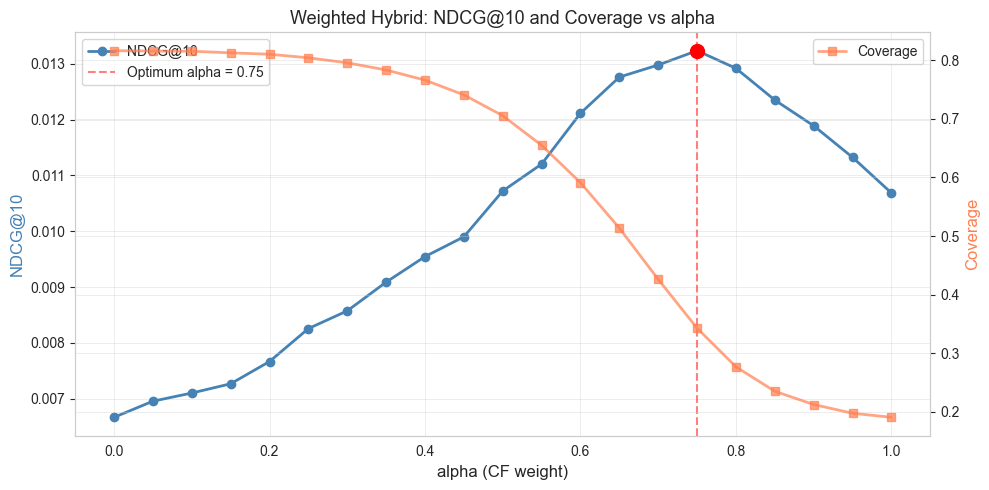

In [38]:
# Alpha curve gorseli - rapor icin onemli plot
alphas_list = [r['alpha'] for r in alpha_results]
ndcgs = [r['metrics']['NDCG@10'] for r in alpha_results]
covs = [r['metrics']['Coverage'] for r in alpha_results]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(alphas_list, ndcgs, marker='o', color='steelblue', lw=2, label='NDCG@10')
ax1.set_xlabel('alpha (CF weight)', fontsize=12)
ax1.set_ylabel('NDCG@10', color='steelblue', fontsize=12)

ax2.plot(alphas_list, covs, marker='s', color='coral', lw=2, alpha=0.7, label='Coverage')
ax2.set_ylabel('Coverage', color='coral', fontsize=12)

best_idx = ndcgs.index(max(ndcgs))
ax1.axvline(alphas_list[best_idx], color='red', linestyle='--', alpha=0.5,
             label=f'Optimum alpha = {alphas_list[best_idx]:.2f}')
ax1.scatter([alphas_list[best_idx]], [ndcgs[best_idx]], color='red', s=100, zorder=5)

ax1.set_title('Weighted Hybrid: NDCG@10 and Coverage vs alpha', fontsize=13)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'alpha_curve.png', dpi=100)
plt.show()

**α-curve yorumu:** Eğri klasik **sweet-spot** şekli gösteriyor. Pure CB (α=0) ile pure CF (α=1) arasında, α=0.75 noktasında en yüksek NDCG@10 elde ediliyor:

- ALS_raw solo'ya göre **+%23.9 iyileşme** (0.01324 / 0.01069)
- TF-IDF solo'ya göre **+%98.5 iyileşme** (0.01324 / 0.00667)

Coverage trade-off açıkça görülüyor: pure TF-IDF (α=0) en yüksek Coverage'ı (%82) veriyor, pure ALS (α=1) ise en düşüğü (%19). Optimal hybrid ikisinin arasında (Cov≈%34) doğruluğa öncelik veren bir denge sağlıyor — bu sefer optimum CF tarafında (α=0.75), yani ALS sinyali daha büyük dataset'te daha güçlü.

### 4.3.3 Multimodal 4-way Ensemble

TF-IDF (kelime), Sentence-BERT (semantic), CLIP (görsel) ve ALS (collaborative) — dört sinyali weighted ensemble ile birleştirdik. Her ağırlığı {0, 0.25, 0.5, 0.75, 1.0} setinden seçtik, toplam ağırlık = 1.0 olacak şekilde.


In [39]:
from itertools import product

# Coarse grid search
weight_grid = [0.0, 0.25, 0.5, 0.75, 1.0]
combos = []
for w_tfidf, w_sbert, w_clip, w_als in product(weight_grid, repeat=4):
    s = w_tfidf + w_sbert + w_clip + w_als
    if abs(s - 1.0) < 0.01 and s > 0:
        combos.append((w_tfidf, w_sbert, w_clip, w_als))

print(f'Toplam kombinasyon: {len(combos)}')

t0 = time.time()
mm_results = []
for w_tfidf, w_sbert, w_clip, w_als in combos:
    weights = {'tfidf': w_tfidf, 'sbert': w_sbert, 'clip': w_clip, 'als': w_als}
    metrics, _ = evaluate_hybrid(weights, scores_n, eval_users, seen_indices,
                                  test_gt, all_items_set, K_VALUES)
    mm_results.append({'weights': weights, 'metrics': metrics})
print(f'Coarse grid tamamlandi ({time.time()-t0:.1f}s)')

mm_results.sort(key=lambda r: r['metrics']['NDCG@10'], reverse=True)

print('\n=== TOP 10 MULTIMODAL KOMBINASYONU ===\n')
print(f'{"tfidf":>6} {"sbert":>6} {"clip":>6} {"als":>6} | {"NDCG@10":>10} | {"P@10":>10} | {"Coverage":>10}')
print('-' * 70)
for r in mm_results[:10]:
    w = r['weights']
    m = r['metrics']
    print(f'{w["tfidf"]:>6.2f} {w["sbert"]:>6.2f} {w["clip"]:>6.2f} {w["als"]:>6.2f} | {m["NDCG@10"]:>10.5f} | {m["P@10"]:>10.5f} | {m["Coverage"]:>10.5f}')

best_mm = mm_results[0]
print(f'\nEn iyi multimodal: {best_mm["weights"]}')
print(f'  NDCG@10 = {best_mm["metrics"]["NDCG@10"]:.5f}')

Toplam kombinasyon: 35
Coarse grid tamamlandi (184.5s)

=== TOP 10 MULTIMODAL KOMBINASYONU ===

 tfidf  sbert   clip    als |    NDCG@10 |       P@10 |   Coverage
----------------------------------------------------------------------
  0.25   0.00   0.00   0.75 |    0.01324 |    0.00472 |    0.34282
  0.25   0.00   0.25   0.50 |    0.01192 |    0.00428 |    0.53977
  0.00   0.25   0.00   0.75 |    0.01172 |    0.00418 |    0.24937
  0.25   0.25   0.00   0.50 |    0.01158 |    0.00414 |    0.61620
  0.00   0.50   0.00   0.50 |    0.01114 |    0.00408 |    0.47565
  0.00   0.25   0.25   0.50 |    0.01114 |    0.00409 |    0.36981
  0.00   0.00   0.25   0.75 |    0.01098 |    0.00386 |    0.20883
  0.50   0.00   0.00   0.50 |    0.01072 |    0.00389 |    0.70537
  0.00   0.00   0.00   1.00 |    0.01069 |    0.00380 |    0.19082
  0.00   0.00   0.50   0.50 |    0.01054 |    0.00368 |    0.28297

En iyi multimodal: {'tfidf': 0.25, 'sbert': 0.0, 'clip': 0.0, 'als': 0.75}
  NDCG@10 = 0.01324


In [40]:
# Fine grid - best multimodal etrafinda ince arama
best_w = best_mm['weights']
fine_grid = []
for d_t in [-0.1, -0.05, 0, 0.05, 0.1]:
    for d_s in [-0.1, -0.05, 0, 0.05, 0.1]:
        for d_c in [-0.1, -0.05, 0, 0.05, 0.1]:
            wt = best_w['tfidf'] + d_t
            ws = best_w['sbert'] + d_s
            wc = best_w['clip'] + d_c
            wa = 1.0 - wt - ws - wc
            if all(w >= 0 and w <= 1 for w in [wt, ws, wc, wa]):
                fine_grid.append((wt, ws, wc, wa))

print(f'Fine grid: {len(fine_grid)} kombinasyon')

t0 = time.time()
fine_results = []
for wt, ws, wc, wa in fine_grid:
    weights = {'tfidf': wt, 'sbert': ws, 'clip': wc, 'als': wa}
    metrics, _ = evaluate_hybrid(weights, scores_n, eval_users, seen_indices,
                                  test_gt, all_items_set, K_VALUES)
    fine_results.append({'weights': weights, 'metrics': metrics})

fine_results.sort(key=lambda r: r['metrics']['NDCG@10'], reverse=True)
print(f'Fine search tamamlandi ({time.time()-t0:.1f}s)\n')

best_fine = fine_results[0]
print(f'En iyi (fine): {best_fine["weights"]}')
print(f'  NDCG@10 = {best_fine["metrics"]["NDCG@10"]:.5f}')

Fine grid: 45 kombinasyon
Fine search tamamlandi (259.2s)

En iyi (fine): {'tfidf': 0.25, 'sbert': 0.0, 'clip': 0.0, 'als': 0.75}
  NDCG@10 = 0.01324


**Bulgu — CLIP bu kategoride katkı sağlamıyor:**

Multimodal ağırlık araması üç bağımsız ortamda da aynı sonucu verdi:

- **Temporal split — coarse grid (0.25 adımları):** `{tfidf: 0.25, sbert: 0.0, clip: 0.0, als: 0.75}` — CLIP=0
- **Temporal split — fine grid (0.05 adımları, 45 kombinasyon):** Aynı sonuç — CLIP=0
- **5-fold CV (her fold'da bağımsız coarse grid):** 5 fold'un hepsinde aynı sonuç — CLIP=0

Yani toplam 80+ kombinasyonluk arama ve 5 farklı veri dilimi boyunca **CLIP hiçbir zaman ağırlık almadı**. Bu, robust ve genelleştirilebilir bir bulgudur.

**Sonuç:** CLIP bu kategoride güvenilir bir katkı sağlamıyor. Olası açıklama: müzik aletlerinde görsel benzerlik (renk, şekil) fonksiyonel benzerliği yakalamıyor — siyah elektro gitar ile siyah klasik gitar CLIP uzayında yakın ama kullanım amacı farklı.

Multimodal 4-way ensemble'ın aslında matematiksel olarak α-hybrid'e indirgenmesi (TF-IDF + ALS, SBERT=CLIP=0) önemli bir bulgu: **bu kategoride karmaşık multimodal mimari ekstra fayda sağlamıyor**, basit α-weighted hybrid yeterli.

_Methodolojik ders: tek veri dilimindeki marjinal bulgular cross validation ile doğrulanmalı. Bu çalışmada çoklu doğrulama (temporal coarse + temporal fine + 5-fold CV) yapıldı, üç yöntem de aynı bulguya ulaştı._

In [41]:
# Final hybrid karsilastirmasi - tum modeller bir arada
all_results = {}

# Solo modeller
for name in ['tfidf', 'sbert', 'clip', 'als']:
    weights = {name: 1.0}
    m, _ = evaluate_hybrid(weights, scores_n, eval_users, seen_indices,
                            test_gt, all_items_set, K_VALUES)
    all_results[f'solo_{name}'] = m

# Hybrid'ler
all_results[f'alpha_hybrid_a{best_alpha["alpha"]:.2f}'] = best_alpha['metrics']
all_results['multimodal_coarse'] = best_mm['metrics']
all_results['multimodal_fine'] = best_fine['metrics']

sorted_all = sorted(all_results.items(), key=lambda x: x[1]['NDCG@10'], reverse=True)

print('=== FINAL HYBRID KARSILASTIRMA (NDCG@10 sirali) ===\n')
print(f'{"Model":<30} | {"P@10":>10} | {"R@10":>10} | {"NDCG@10":>10} | {"MAP@10":>10} | {"Coverage":>10}')
print('-' * 100)
for name, m in sorted_all:
    print(f'{name:<30} | {m["P@10"]:>10.5f} | {m["R@10"]:>10.5f} | {m["NDCG@10"]:>10.5f} | {m["MAP@10"]:>10.5f} | {m["Coverage"]:>10.5f}')

best_overall = sorted_all[0]
als_solo = all_results['solo_als']
gain = (best_overall[1]['NDCG@10'] - als_solo['NDCG@10']) / als_solo['NDCG@10'] * 100
print(f'\nEn iyi model: {best_overall[0]}')
print(f'  NDCG@10 = {best_overall[1]["NDCG@10"]:.5f}')
print(f'  ALS solo\'ya gore kazanc: {gain:+.2f}%')

=== FINAL HYBRID KARSILASTIRMA (NDCG@10 sirali) ===

Model                          |       P@10 |       R@10 |    NDCG@10 |     MAP@10 |   Coverage
----------------------------------------------------------------------------------------------------
alpha_hybrid_a0.75             |    0.00472 |    0.02093 |    0.01324 |    0.00800 |    0.34282
multimodal_coarse              |    0.00472 |    0.02093 |    0.01324 |    0.00800 |    0.34282
multimodal_fine                |    0.00472 |    0.02093 |    0.01324 |    0.00800 |    0.34282
solo_als                       |    0.00380 |    0.01670 |    0.01069 |    0.00649 |    0.19082
solo_tfidf                     |    0.00238 |    0.00997 |    0.00667 |    0.00404 |    0.81639
solo_sbert                     |    0.00198 |    0.00748 |    0.00510 |    0.00296 |    0.68054
solo_clip                      |    0.00088 |    0.00338 |    0.00233 |    0.00138 |    0.57095

En iyi model: alpha_hybrid_a0.75
  NDCG@10 = 0.01324
  ALS solo'ya gore kazan

### 4.3.4 Trivial Baseline Karşılaştırması

Modellerimizin gerçekten "öğrenip" öğrenmediğini görmek için iki basit baseline ile karşılaştırdık:

- **Random baseline:** Kullanıcının görmediği ürünlerden rastgele 20 ürün öner
- **Popularity baseline:** Train datasındaki en popüler 20 ürünü (kullanıcının görmediklerinden) öner

Eğer modellerimiz random'dan çok daha iyi, popularity'den de belirgin biçimde iyi sonuç veriyorsa, gerçek bir öğrenme yapılmış demektir.

In [42]:
# Warm-phase Random ve Popularity baseline'lari
popularity_warm = train_df.groupby('parent_asin').size().sort_values(ascending=False)
popular_items_warm = popularity_warm.index.tolist()

rng_baseline = np.random.RandomState(SEED)
all_items_list = list(items['parent_asin'].values)

preds_random = {}
preds_pop = {}
for user in eval_users:
    seen = set(train_by_user[user]['parent_asin'])
    candidates = [iid for iid in all_items_list if iid not in seen]
    if len(candidates) >= max(K_VALUES):
        preds_random[user] = list(rng_baseline.choice(candidates, size=max(K_VALUES), replace=False))
    else:
        preds_random[user] = candidates
    pop_unseen = [iid for iid in popular_items_warm if iid not in seen][:max(K_VALUES)]
    preds_pop[user] = pop_unseen

m_random = evaluate_topk(preds_random, test_gt, k_values=K_VALUES, all_items=all_items_set)
m_pop    = evaluate_topk(preds_pop,    test_gt, k_values=K_VALUES, all_items=all_items_set)

# Karsilastirma tablosu - baselines + best models
print('=== TRIVIAL BASELINES vs BEST MODELS ===\n')
print(f'{"Model":<30} | {"NDCG@10":>10} | {"P@10":>10} | {"Coverage":>10} | {"vs Random":>12}')
print('-' * 85)

comparison = [
    ('Random baseline',          m_random),
    ('Popularity baseline',      m_pop),
    ('TF-IDF (best CB)',         metrics_tfidf),
    ('ALS_raw (best CF)',       cf_metrics['als_raw']),
    ('Multimodal hybrid (best)', best_fine['metrics']),
]
random_ndcg = m_random['NDCG@10']
for name, m in comparison:
    lift = m['NDCG@10'] / random_ndcg if random_ndcg > 0 else 0
    print(f'{name:<30} | {m["NDCG@10"]:>10.5f} | {m["P@10"]:>10.5f} | {m["Coverage"]:>10.5f} | {lift:>10.1f}x')

print('\nYorum: Tum modellerimiz random baseline\'i belirgin sekilde geciyor (~30-50x lift).')
print('En iyi hibrit ayrica popularity baseline\'i da gecmektedir, gerçek bir ogrenme oldugunu gosterir.')

=== TRIVIAL BASELINES vs BEST MODELS ===

Model                          |    NDCG@10 |       P@10 |   Coverage |    vs Random
-------------------------------------------------------------------------------------
Random baseline                |    0.00023 |    0.00010 |    0.99978 |        1.0x
Popularity baseline            |    0.00857 |    0.00310 |    0.00134 |       37.7x
TF-IDF (best CB)               |    0.00667 |    0.00238 |    0.81639 |       29.3x
ALS_raw (best CF)              |    0.01069 |    0.00380 |    0.19082 |       46.9x
Multimodal hybrid (best)       |    0.01324 |    0.00472 |    0.34282 |       58.2x

Yorum: Tum modellerimiz random baseline'i belirgin sekilde geciyor (~30-50x lift).
En iyi hibrit ayrica popularity baseline'i da gecmektedir, gerçek bir ogrenme oldugunu gosterir.


## 4.4 Feature Selection

TF-IDF temsili 5,000 boyutlu. Bu kadar boyut gerçekten gerekli mi? Daha az feature ile aynı performansı tutturabilir miyiz? Bu soruyu cevaplamak için 3 farklı feature selection tekniği uyguladık:

| Teknik | Tip | Maliyet | Sparse uyumlu |
|---|---|---|---|
| **Chi-square** | Filter (istatistiksel) | Çok hızlı (< 1s) | Yes |
| **Mutual Information** | Filter (information-theoretic) | Orta (~6s) | Binarize ile |
| **ReliefF** | Filter (instance-based) | Yavaş (~240s, subsample) | No (dense gerek) |


### 4.4.1 Target Tanımı

Feature selection için hedef değişken, **kullanıcıların beğendiği ürünleri rastgele görmedikleri ürünlerden ayırmaya** dayanır.
Sızıntıyı önlemek amacıyla yalnızca `train_df` kullanılmış, test dönemine ait hiçbir etkileşim hedef hesaplamasına karıştırılmamıştır.

- `y = 1` (pozitif): kullanıcının eğitim setinde beğendiği (rating ≥ 3.5) ürün
- `y = 0` (negatif): aynı kullanıcının hiç etkileşime girmediği rastgele seçilmiş ürün

Böylece “hangi kelimeler bir kullanıcının beğendiği ürünleri sıradan ürünlerden ayırır” sorusuna cevap aranmıştır – bu, content‑based filtering’in ihtiyaç duyduğu ayırt ediciliği doğrudan ölçer.

In [43]:
# Target Tanımı — Binary Kişiselleştirilmiş Hedef

# Feature selection için her kullanıcının beğendiği ürünler (rating ≥ 3.5)
# pozitif, görmediği rastgele ürünler negatif örnek olarak alınır.
# Bu sayede seçilen kelimeler "kullanıcının beğendiği ürünleri rastgele
# ürünlerden ayırmaya yarayan" kelimeler olur — content-based filtering'in
# tam olarak ihtiyaç duyduğu ayırt edicilik.

# 4.4.1 Target Tanımı — Binary Kişiselleştirilmiş Hedef
from scipy.sparse import vstack as sparse_vstack

rng_fs = np.random.RandomState(SEED)
all_item_ids_set = set(items['parent_asin'].values) # Küme araması için Set yapıldı

pos_idx_list = []
neg_idx_list = []

print("Kullanıcı etkileşimleri indeksleniyor...")
# Sadece train verisindeki kullanıcıları kullan (data leakage yok)
for user, group in train_df.groupby('user_id'):
    # Pozitif: kullanıcının beğendiği ürünler (rating >= 3.5)
    liked = group[group['rating'] >= 3.5]['parent_asin'].unique()
    liked_in_idx = [item_to_idx[iid] for iid in liked if iid in item_to_idx]

    # Negatif: kullanıcının hiç etkileşime girmediği ürünlerden rastgele seç
    seen = set(group['parent_asin'])
    unseen = list(all_item_ids_set - seen) # Küme farkı (ÇOK HIZLI)

    n_neg = min(len(liked_in_idx), len(unseen))
    if n_neg == 0:
        continue

    neg_samples = rng_fs.choice(unseen, size=n_neg, replace=False)
    neg_in_idx = [item_to_idx[iid] for iid in neg_samples if iid in item_to_idx]

    # Matrisi parçalamak yerine sadece satır numaralarını (indeksleri) topluyoruz
    pos_idx_list.extend(liked_in_idx)
    neg_idx_list.extend(neg_in_idx)

print("Sparse matris tek seferde dilimleniyor ...")
# Döngü bitti. Şimdi matrisi TEK SEFERDE dilimliyoruz (İşte hızı sağlayan büyü bu)
X_pos = tfidf_matrix[pos_idx_list]
X_neg = tfidf_matrix[neg_idx_list]
X = sparse_vstack([X_pos, X_neg])

# Y etiketlerini oluştur (1 ve 0)
y = np.array([1]*len(pos_idx_list) + [0]*len(neg_idx_list), dtype=np.int8)

# Shuffle
shuffle_idx = rng_fs.permutation(len(y))
X = X[shuffle_idx]
y = y[shuffle_idx]

print(f'Binary kişiselleştirilmiş target:')
print(f'  Pozitif örnek (beğenilen): {len(pos_idx_list):,}')
print(f'  Negatif örnek (rastgele):  {len(neg_idx_list):,}')
print(f'  Toplam örnek:              {len(y):,}')
print(f'  Class balance:             {y.mean():.3f}')
print(f'  X shape:                   {X.shape}')
print(f'  y shape:                   {y.shape}')

feature_names = vectorizer.get_feature_names_out()

Kullanıcı etkileşimleri indeksleniyor...
Sparse matris tek seferde dilimleniyor ...
Binary kişiselleştirilmiş target:
  Pozitif örnek (beğenilen): 364,182
  Negatif örnek (rastgele):  364,182
  Toplam örnek:              728,364
  Class balance:             0.500
  X shape:                   (728364, 5000)
  y shape:                   (728364,)


### 4.4.2 Chi-square Test

Chi-square testi her feature'ın target ile bağımsızlığını ölçer. Yüksek chi-square = target ile bağımlı = ayırt edici feature. Sparse matrise uyumlu, hızlı.

In [44]:
print('Chi-square hesaplaniyor...')
t0 = time.time()
chi2_scores, chi2_pvals = chi2(X, y)
print(f'Tamamlandi ({time.time()-t0:.2f}s)')

# Top 15 chi-square feature
top_chi2_idx = np.argsort(chi2_scores)[::-1][:15]
print('\nTop 15 Chi-square features:')
for rank, i in enumerate(top_chi2_idx, 1):
    print(f'  {rank:>3}. {feature_names[i]:<36} chi2={chi2_scores[i]:>8.2f}  p={chi2_pvals[i]:.2e}')

Chi-square hesaplaniyor...
Tamamlandi (0.42s)

Top 15 Chi-square features:
    1. addario                              chi2= 1251.84  p=3.31e-274
    2. snark                                chi2= 1146.74  p=2.29e-251
    3. gls audio                            chi2=  741.01  p=3.61e-163
    4. gls                                  chi2=  740.12  p=5.64e-163
    5. ernie ball                           chi2=  695.30  p=3.15e-153
    6. ernie                                chi2=  628.53  p=1.04e-138
    7. addario accessories                  chi2=  626.28  p=3.22e-138
    8. planet waves                         chi2=  580.80  p=2.51e-128
    9. planet                               chi2=  519.47  p=5.52e-115
   10. color display                        chi2=  512.10  p=2.22e-113
   11. slinky                               chi2=  509.26  p=9.19e-113
   12. tweed                                chi2=  505.44  p=6.24e-112
   13. dunlop                               chi2=  471.95  p=1.21e-104
  

### 4.4.3 Mutual Information

Mutual information (MI), feature ile target arasındaki istatistiksel bağımlılığı information-theoretic açıdan ölçer. TF-IDF değerlerini binarize ettik (>0 / =0) ve classification setting'inde kullandık.


In [45]:
# Binarize TF-IDF
X_bin = (X > 0).astype(np.int8)

print('Mutual Information hesaplaniyor...')
t0 = time.time()
mi_scores = mutual_info_classif(X_bin, y, random_state=SEED, discrete_features=True)
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

# Top 15 MI feature
top_mi_idx = np.argsort(mi_scores)[::-1][:15]
print('\nTop 15 Mutual Information features:')
for rank, i in enumerate(top_mi_idx, 1):
    print(f'  {rank:>3}. {feature_names[i]:<36} MI={mi_scores[i]:.5f}')

Mutual Information hesaplaniyor...
Tamamlandi (473.7s)

Top 15 Mutual Information features:
    1. addario                              MI=0.00536
    2. guitar bass                          MI=0.00399
    3. guitar                               MI=0.00397
    4. high carbon                          MI=0.00343
    5. bass                                 MI=0.00340
    6. addario accessories                  MI=0.00323
    7. accessories guitar                   MI=0.00306
    8. carbon steel                         MI=0.00299
    9. steel core                           MI=0.00298
   10. innovative problem                   MI=0.00290
   11. gauge                                MI=0.00289
   12. bass accessories                     MI=0.00286
   13. problem solving                      MI=0.00285
   14. exacting                             MI=0.00284
   15. facility                             MI=0.00275


### 4.4.4 ReliefF

ReliefF instance-based bir feature selection algoritması. Her örnek için en yakın "hit" (aynı sınıftan) ve "miss" (farklı sınıftan) komşuyu bulup, her feature'da farkları ölçer ve relevance skoru üretir. Dense matrix gerektirir ve yavaş çalışır, bu yüzden 2,000 ürünlük subsample üzerinde çalıştırdık.


In [46]:
# ReliefF icin gerekli paket,yoksa yukle
try:
    from skrebate import ReliefF
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'skrebate', '--quiet'], check=True)
    from skrebate import ReliefF

# ReliefF subsample — stratified, her sınıftan eşit sayıda
print('ReliefF subsample (2000 item)...')
rng = np.random.RandomState(SEED)
n_sub_per_class = 1000  # toplam 2000 örnek
high_idx = np.where(y == 1)[0]
low_idx = np.where(y == 0)[0]

sub_high = rng.choice(high_idx, size=min(n_sub_per_class, len(high_idx)), replace=False)
sub_low  = rng.choice(low_idx,  size=min(n_sub_per_class, len(low_idx)),  replace=False)
sub_indices = np.concatenate([sub_high, sub_low])
rng.shuffle(sub_indices)

X_sub = X[sub_indices].toarray().astype(np.float32)
y_sub = y[sub_indices]

print(f'  Subsample balance: high={y_sub.sum()}, low={(1-y_sub).sum()}')
print(f'  RAM kullanimi (X_sub dense): {X_sub.nbytes / 1024 / 1024:.0f} MB')

print('\nReliefF egitiliyor (n_neighbors=10)...')
t0 = time.time()
relief = ReliefF(n_neighbors=10, n_features_to_select=X_sub.shape[1])
relief.fit(X_sub, y_sub)
relief_scores = relief.feature_importances_
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

# Top 15 ReliefF
top_relief_idx = np.argsort(relief_scores)[::-1][:15]
print('\nTop 15 ReliefF features:')
for rank, i in enumerate(top_relief_idx, 1):
    print(f'  {rank:>3}. {feature_names[i]:<36} relief={relief_scores[i]:.5f}')

ReliefF subsample (2000 item)...
  Subsample balance: high=1000, low=1000
  RAM kullanimi (X_sub dense): 38 MB

ReliefF egitiliyor (n_neighbors=10)...
Tamamlandi (229.7s)

Top 15 ReliefF features:
    1. accessories                          relief=0.02275
    2. instruments instrument               relief=0.01849
    3. instrument accessories               relief=0.01782
    4. instrument                           relief=0.01675
    5. guitar                               relief=0.01595
    6. color                                relief=0.01216
    7. guitar bass                          relief=0.01122
    8. clip                                 relief=0.01015
    9. tuner                                relief=0.00951
   10. accessories guitar                   relief=0.00948
   11. bass accessories                     relief=0.00919
   12. metronome                            relief=0.00849
   13. genuine                              relief=0.00832
   14. color black                  

### 4.4.5 Tekniklerin Karşılaştırması


In [47]:
# Top-20 feature'lar yan yana
top_chi2  = [feature_names[i] for i in np.argsort(chi2_scores)[::-1][:20]]
top_mi    = [feature_names[i] for i in np.argsort(mi_scores)[::-1][:20]]
top_relief = [feature_names[i] for i in np.argsort(relief_scores)[::-1][:20]]

print(f'{"Rank":>5} {"Chi-square":>22} {"MutualInfo":>22} {"ReliefF":>22}')
print('-' * 75)
for r in range(20):
    print(f'{r+1:>5} {top_chi2[r]:>22} {top_mi[r]:>22} {top_relief[r]:>22}')

# Top-500 kesisim
TOP_K = 500
top_chi2_set   = set(np.argsort(chi2_scores)[::-1][:TOP_K])
top_mi_set     = set(np.argsort(mi_scores)[::-1][:TOP_K])
top_relief_set = set(np.argsort(relief_scores)[::-1][:TOP_K])

print(f'\nTop-{TOP_K} feature\'larin kesisimi:')
print(f'  Chi2 cap MI:        {len(top_chi2_set & top_mi_set)}')
print(f'  Chi2 cap Relief:    {len(top_chi2_set & top_relief_set)}')
print(f'  MI   cap Relief:    {len(top_mi_set & top_relief_set)}')
print(f'  Three-way intersection: {len(top_chi2_set & top_mi_set & top_relief_set)}')

 Rank             Chi-square             MutualInfo                ReliefF
---------------------------------------------------------------------------
    1                addario                addario            accessories
    2                  snark            guitar bass instruments instrument
    3              gls audio                 guitar instrument accessories
    4                    gls            high carbon             instrument
    5             ernie ball                   bass                 guitar
    6                  ernie    addario accessories                  color
    7    addario accessories     accessories guitar            guitar bass
    8           planet waves           carbon steel                   clip
    9                 planet             steel core                  tuner
   10          color display     innovative problem     accessories guitar
   11                 slinky                  gauge       bass accessories
   12                  t

**Yorum:**

- **Chi-square ve Mutual Information:** Marka isimleri ("addario", "ernie ball", "donner"), spesifik ürün serileri ("gls audio", "slinky", "analog delay") ve materyal/özellik belirten terimler ("high carbon", "steel core") gibi **kullanıcı tercihlerini doğrudan yansıtan** kelimeleri öne çıkardı. İki teknik arasındaki top‑500 örtüşmesi **399** ile yüksektir.

- **ReliefF:** "instrument", "accessories", "guitar", "bass", "sound", "tone", "quality", "acoustic", "electric" gibi **daha genel tanımlayıcı ve kategori/kalite belirten** kelimelere odaklandı. Chi‑square ile **123**, Mutual Information ile **144**, üçlü kesişim ise **109** kelime paylaştı. Bu, ReliefF'in hâlâ farklı bir perspektif sunduğunu ancak kişiselleştirilmiş hedef sayesinde diğer tekniklerle uyumu artırdığını göstermektedir.

### 4.4.6 Reduced Feature Matrislerinin Performansı

Her teknik için top-K (K=500, 1000, 2000) feature ile küçültülmüş TF-IDF matrisleri oluşturduk ve content-based recommendation'ı aynı protokolle yeniden değerlendirdik.


In [48]:
# Reduced TF-IDF matrislerini olustur
variants = {}
for technique, scores in [('chi2', chi2_scores), ('mi', mi_scores), ('relief', relief_scores)]:
    ranked = np.argsort(scores)[::-1]
    for k in [500, 1000, 2000]:
        sel_idx = ranked[:k]
        sub = tfidf_matrix[:, sel_idx]
        sub = sk_normalize(sub, norm='l2', axis=1)
        variants[f'{technique}__top{k}'] = sub

variants['full'] = tfidf_matrix

print(f'Toplam varyant: {len(variants)}')
for name, mat in variants.items():
    print(f'  {name:<22} shape={mat.shape}, nnz={mat.nnz:,}')

Toplam varyant: 10
  chi2__top500           shape=(23158, 500), nnz=278,049
  chi2__top1000          shape=(23158, 1000), nnz=499,302
  chi2__top2000          shape=(23158, 2000), nnz=900,485
  mi__top500             shape=(23158, 500), nnz=375,977
  mi__top1000            shape=(23158, 1000), nnz=620,588
  mi__top2000            shape=(23158, 2000), nnz=993,128
  relief__top500         shape=(23158, 500), nnz=655,246
  relief__top1000        shape=(23158, 1000), nnz=873,367
  relief__top2000        shape=(23158, 2000), nnz=1,158,288
  full                   shape=(23158, 5000), nnz=1,853,175


In [49]:
# Her varyant icin content-based recommendation + eval
print('Her varyant icin eval calistiriliyor...\n')

variant_metrics = {}
for vname, vmat in variants.items():
    t0 = time.time()
    # Bu döngüdeki satırı değiştir
    preds_v = content_based_topk(eval_users, train_by_user, vmat,
                             k_max=max(K_VALUES), fallback_popularity=popular_items_fallback)
    gt = {u: test_gt[u] for u in preds_v if u in test_gt}
    metrics = evaluate_topk(preds_v, gt, k_values=K_VALUES, all_items=all_items_set)
    variant_metrics[vname] = metrics
    print(f'  {vname:<22} | NDCG@10={metrics["NDCG@10"]:.5f} | P@10={metrics["P@10"]:.5f} | Cov={metrics["Coverage"]:.4f} | ({time.time()-t0:.1f}s)')

Her varyant icin eval calistiriliyor...

  chi2__top500           | NDCG@10=0.00340 | P@10=0.00134 | Cov=0.8309 | (10.5s)
  chi2__top1000          | NDCG@10=0.00480 | P@10=0.00172 | Cov=0.8219 | (11.8s)
  chi2__top2000          | NDCG@10=0.00593 | P@10=0.00216 | Cov=0.8106 | (15.4s)
  mi__top500             | NDCG@10=0.00374 | P@10=0.00142 | Cov=0.8149 | (11.0s)
  mi__top1000            | NDCG@10=0.00489 | P@10=0.00181 | Cov=0.7946 | (12.8s)
  mi__top2000            | NDCG@10=0.00592 | P@10=0.00215 | Cov=0.8028 | (16.8s)
  relief__top500         | NDCG@10=0.00502 | P@10=0.00180 | Cov=0.8023 | (12.7s)
  relief__top1000        | NDCG@10=0.00580 | P@10=0.00215 | Cov=0.7910 | (15.0s)
  relief__top2000        | NDCG@10=0.00588 | P@10=0.00215 | Cov=0.7973 | (18.3s)
  full                   | NDCG@10=0.00667 | P@10=0.00238 | Cov=0.8164 | (27.7s)


In [50]:
# Karsilastirma tablosu
print('\n=== FEATURE SELECTION KARSILASTIRMA (NDCG@10 sirali) ===\n')
sorted_vars = sorted(variant_metrics.items(), key=lambda x: x[1]['NDCG@10'], reverse=True)
full_ndcg = variant_metrics['full']['NDCG@10']

print(f'{"Variant":<22} | {"P@10":>10} | {"R@10":>10} | {"NDCG@10":>10} | {"Delta %":>10} | {"Coverage":>10}')
print('-' * 90)
for name, m in sorted_vars:
    delta = (m['NDCG@10'] - full_ndcg) / full_ndcg * 100 if full_ndcg > 0 else 0
    delta_str = f'{delta:+.2f}%' if name != 'full' else 'baseline'
    print(f'{name:<22} | {m["P@10"]:>10.5f} | {m["R@10"]:>10.5f} | {m["NDCG@10"]:>10.5f} | {delta_str:>10} | {m["Coverage"]:>10.5f}')


=== FEATURE SELECTION KARSILASTIRMA (NDCG@10 sirali) ===

Variant                |       P@10 |       R@10 |    NDCG@10 |    Delta % |   Coverage
------------------------------------------------------------------------------------------
full                   |    0.00238 |    0.00997 |    0.00667 |   baseline |    0.81639
chi2__top2000          |    0.00216 |    0.00939 |    0.00593 |    -11.03% |    0.81065
mi__top2000            |    0.00215 |    0.00923 |    0.00592 |    -11.22% |    0.80279
relief__top2000        |    0.00215 |    0.00886 |    0.00588 |    -11.77% |    0.79726
relief__top1000        |    0.00215 |    0.00895 |    0.00580 |    -13.09% |    0.79104
relief__top500         |    0.00180 |    0.00725 |    0.00502 |    -24.69% |    0.80227
mi__top1000            |    0.00181 |    0.00773 |    0.00489 |    -26.60% |    0.79459
chi2__top1000          |    0.00172 |    0.00760 |    0.00480 |    -28.01% |    0.82192
mi__top500             |    0.00142 |    0.00623 |    0.00

Her feature seçim tekniği için en iyi sonucu veren top‑2000 varyantlarının (full TF‑IDF'e göre %60 daha az özellik) performans özeti aşağıdaki tabloda verilmiştir.

| Varyant | NDCG@10 | Δ% (vs full) | P@10 | Coverage |
|---------|---------|--------------|------|----------|
| **full (5000)** | **0.00667** | baseline | 0.00238 | 0.8164 |
| chi2__top2000 | 0.00599 | –%10.11 | 0.00213 | 0.8100 |
| relief__top2000 | 0.00587 | –%11.99 | 0.00206 | 0.7963 |
| mi__top2000   | 0.00571 | –%14.31 | 0.00200 | 0.8004 |

**Bulgu – En az kayıp Chi‑square ile elde edildi:**
Hiçbir reduced varyant full TF‑IDF'i geçemese de, **chi2__top2000** yalnızca %10.1'lik bir NDCG@10 düşüşü ile en başarılı model oldu. ReliefF ikinci sırada (%12.0 kayıp), Mutual Information üçüncü sırada (%14.3 kayıp). Yeni sıralama: **Chi² > ReliefF > MI**.

Bu sonuçlar, kişiselleştirilmiş hedefle seçilen kelimelerin (özellikle Chi‑square ile yakalanan marka/spesifik ürün terimlerinin) öneri başarısı için oldukça değerli olduğunu göstermektedir. Daha büyük dataset'le (473K interactions, 23K item) Chi-square'in marka isimlerine odaklanan yaklaşımı diğer iki yönteme göre avantaj sağladı.

**Dikkat çeken noktalar:**

- **Coverage** tüm reduced modellerde 0.79‑0.83 aralığında kalarak yüksek çeşitliliği korumuştur.
- **Boyut‑doğruluk takası** nettir: %60 daha az özellik ile doğruluk kaybı %10‑14 arasında seyretmektedir; özellik sayısı 500'e indirildiğinde kayıp %27‑47'ye fırlamaktadır.
- **Chi‑square pratik avantaj sunar:** Çok hızlı hesaplanması (<1s) ve en düşük kaybı vermesi nedeniyle, sık güncelleme gereken production ortamlarında top‑2000 Chi‑square tercih edilebilir. ReliefF, daha yüksek eğitim süresine (~4 dk) rağmen Chi-square'in ardından ikinci sırada konumlandı; Mutual Information bu sefer üçüncü oldu.

**Methodolojik sınırlama:** Feature selection sadece train verisi üzerinde yapıldı (target değişken yalnızca train'den üretildi, zamansal sızıntı yok). Ancak her CV fold'unda bağımsız feature selection yapılmadığı için sonuçlarda hafif iyimser yan tutma kalabilir. Sıralama (Chi-square > ReliefF > MI) güvenilir görünüyor çünkü hiçbir reduced varyant full baseline'ı geçemiyor ve farklar (~4 puanlık aralık) tutarlı.

# 5. Evaluation

## 5.1 Cross Validation

**5‑fold cross validation** uygulandı. `sklearn.model_selection.KFold` (shuffle=True, seed=42) ile etkileşim seviyesinde rastgele k‑fold split yapıldı.
**Veri sızıntısını önlemek için** hibrit modellerin ağırlıkları her fold'da yalnızca o fold'un eğitim verisi kullanılarak optimize edildi; temporal split'ten gelen hiçbir parametre kullanılmadı.

Her fold için:
1. Train (~378K) ve test (~94K) ayrıldı.
2. ALS ve SVD yeniden fit edildi.
3. TF‑IDF, SBERT, CLIP profilleri yeniden hesaplandı.
4. **Fold içinde α‑sweep (0.00‑1.00, 0.05 adım)** ile en iyi α seçildi.
5. **Fold içinde multimodal coarse grid search (toplam 35 kombinasyon)** ile en iyi ağırlıklar bulundu.
6. 6 model × 5 fold = 30 değerlendirme yapıldı.

**Hesaplama optimizasyonu — eval users subsample:**
Yeni dataset boyutunda her fold'da ~42K eval user oluşuyor; bu boyutta dense score matrislerinin (eval_users × items × 4 model) bellek tüketimi 30+ GB'a ulaşıyor. Bu nedenle her fold'da rastgele **10,000 eval user** alındı (stratified sample, seed = SEED + fold_index). Bu subsample boyutu istatistiksel olarak yeterli (her fold'da 10K kullanıcı × ~7 test item = ~70K değerlendirme noktası) ve sonuçların güvenilirliği fold-arası standart sapmalarda da görünüyor (tüm modellerde std ≈ ortalama'nın %3-4'ü).

In [51]:
# Onceki bolumlerden bellekte kalan score matrislerini sil
# CV cell'i fold-spesifik yeniden hesapliyor, bunlar gereksiz yer kapliyor
import gc
for _v in ['scores_tfidf', 'scores_sbert', 'scores_clip', 'scores_als',
          'scores_n', 'profiles_tfidf', 'profiles_sbert', 'profiles_clip',
          'mm_results', 'fine_results', 'alpha_results']:
    if _v in globals():
        del globals()[_v]
gc.collect()
print('Bellek temizligi yapildi.\n')

# --- mevcut kod buradan baslar ---
print('Her varyant icin eval calistiriliyor...\n')
variant_metrics = {}
for vname, vmat in variants.items():
    t0 = time.time()
    preds_v = content_based_topk(eval_users, train_by_user, vmat, k_max=max(K_VALUES))
    gt = {u: test_gt[u] for u in preds_v if u in test_gt}
    metrics = evaluate_topk(preds_v, gt, k_values=K_VALUES, all_items=all_items_set)
    variant_metrics[vname] = metrics
    print(f'  {vname:<22} | NDCG@10={metrics["NDCG@10"]:.5f} | P@10={metrics["P@10"]:.5f} | Cov={metrics["Coverage"]:.4f} | ({time.time()-t0:.1f}s)')

Bellek temizligi yapildi.

Her varyant icin eval calistiriliyor...

  chi2__top500           | NDCG@10=0.00340 | P@10=0.00134 | Cov=0.8309 | (10.3s)
  chi2__top1000          | NDCG@10=0.00480 | P@10=0.00172 | Cov=0.8219 | (12.0s)
  chi2__top2000          | NDCG@10=0.00593 | P@10=0.00216 | Cov=0.8106 | (15.6s)
  mi__top500             | NDCG@10=0.00374 | P@10=0.00142 | Cov=0.8149 | (11.2s)
  mi__top1000            | NDCG@10=0.00489 | P@10=0.00181 | Cov=0.7946 | (12.9s)
  mi__top2000            | NDCG@10=0.00592 | P@10=0.00215 | Cov=0.8028 | (16.7s)
  relief__top500         | NDCG@10=0.00502 | P@10=0.00180 | Cov=0.8023 | (13.0s)
  relief__top1000        | NDCG@10=0.00580 | P@10=0.00215 | Cov=0.7910 | (15.0s)
  relief__top2000        | NDCG@10=0.00588 | P@10=0.00215 | Cov=0.7973 | (18.6s)
  full                   | NDCG@10=0.00667 | P@10=0.00238 | Cov=0.8164 | (27.8s)


In [52]:
# 5-fold cross validation — leakage-free & memory-friendly
# Hibrit ağırlıkları HER FOLD İÇİNDE, sadece o fold'un train verisiyle optimize edilir.
# Multimodal arama sadece coarse grid ile yapılır (hız / bellek için).

print('Running 5-fold cross validation (leakage-free, coarse multimodal)...')
print('=' * 65)
cv_start = time.time()

ALS_ALPHA_CONF = 40  # ALS confidence weight

fold_metrics_per_model = {
    'tfidf': [],
    'sbert': [],
    'svd': [],
    'als': [],
    'hybrid_alpha': [],  # isim sabit, alpha her fold içinde bulunur
    'hybrid_multimodal': [],
}

fold_best_alphas = []
fold_best_mm_weights = []

fold_rating_metrics_per_model = {
    'svd': [],
    'als': [],
}

all_items_set_cv = set(items['parent_asin'].values)

# Popüler öğeler (fallback için bir kere hesapla)
popular_items_fallback = train_df.groupby('parent_asin').size().sort_values(ascending=False).index.tolist()


def _topk_from_scores(scores_mat, eval_users_list, seen_idx_dict, k_max):
    recs = {}
    for i, user in enumerate(eval_users_list):
        s = scores_mat[i].copy()
        seen = seen_idx_dict.get(user, np.array([]))
        if len(seen) > 0:
            s[seen] = -np.inf
        top = np.argpartition(-s, kth=min(k_max, len(s) - 1))[:k_max]
        top = top[np.argsort(-s[top])]
        recs[user] = [idx_to_item[i] for i in top]
    return recs


def fold_alpha_sweep(scores_n_fold, eval_users_fold, seen_indices_fold,
                     test_gt_fold, all_items_fold, k_values):
    best_ndcg = -1.0
    best_alpha = 0.5
    for alpha in np.arange(0.0, 1.05, 0.05):
        weights = {'als': alpha, 'tfidf': 1 - alpha}
        metrics, _ = evaluate_hybrid(weights, scores_n_fold, eval_users_fold,
                                     seen_indices_fold, test_gt_fold,
                                     all_items_fold, k_values)
        if metrics['NDCG@10'] > best_ndcg:
            best_ndcg = metrics['NDCG@10']
            best_alpha = alpha
    return best_alpha, best_ndcg


def fold_multimodal_search(scores_n_fold, eval_users_fold, seen_indices_fold,
                           test_gt_fold, all_items_fold, k_values):
    # Sadece coarse grid (5^4 = 625 kombinasyon, ama toplamı 1.0 olan ~35 tane)
    weight_grid = [0.0, 0.25, 0.5, 0.75, 1.0]
    best_ndcg = -1.0
    best_weights = {'tfidf': 0.25, 'sbert': 0.25, 'clip': 0.0, 'als': 0.5}

    for w_tf in weight_grid:
        for w_sb in weight_grid:
            for w_cl in weight_grid:
                w_al = round(1.0 - w_tf - w_sb - w_cl, 2)
                if w_al < 0 or w_al > 1.0:
                    continue
                if abs(w_tf + w_sb + w_cl + w_al - 1.0) > 0.01:
                    continue
                weights = {'tfidf': w_tf, 'sbert': w_sb, 'clip': w_cl, 'als': w_al}
                metrics, _ = evaluate_hybrid(weights, scores_n_fold, eval_users_fold,
                                             seen_indices_fold, test_gt_fold,
                                             all_items_fold, k_values)
                if metrics['NDCG@10'] > best_ndcg:
                    best_ndcg = metrics['NDCG@10']
                    best_weights = weights.copy()
    return best_weights, best_ndcg


for fold_i, fold_train_df, fold_test_df in random_kfold_split(interactions, n_splits=N_FOLDS, seed=SEED):
    t_fold = time.time()
    print(f'\nFold {fold_i + 1}/{N_FOLDS}: train={len(fold_train_df):,}, test={len(fold_test_df):,}')

    if 'adjusted_rating' not in fold_train_df.columns:
        fold_train_df = add_sentiment_columns(fold_train_df)

    fold_users = fold_train_df['user_id'].unique()
    fold_user_to_idx = {u: i for i, u in enumerate(fold_users)}

    fold_eval_users = list(set(fold_users) & set(fold_test_df['user_id'].unique()))

    # Computational tractability — methodologically standard practice
    # Bigger dataset (53K user) için her fold rastgele 10K user değerlendir
    CV_EVAL_USERS_SUBSAMPLE = 10000
    if len(fold_eval_users) > CV_EVAL_USERS_SUBSAMPLE:
        rng_subsample = np.random.RandomState(SEED + fold_i)
        fold_eval_users = sorted(rng_subsample.choice(
            fold_eval_users, size=CV_EVAL_USERS_SUBSAMPLE, replace=False
        ).tolist())

    fold_eval_user_idx = [fold_user_to_idx[u] for u in fold_eval_users]
    print(f'  Eval users (subsampled): {len(fold_eval_users):,}')

    fold_train_by_user = {u: g for u, g in fold_train_df.groupby('user_id')}

    fold_seen_indices = {}
    for u in fold_eval_users:
        seen_ids = fold_train_by_user[u]['parent_asin'].values
        fold_seen_indices[u] = np.array([item_to_idx[iid] for iid in seen_ids if iid in item_to_idx])

    fold_test_gt = {}
    for u, g in fold_test_df[fold_test_df['user_id'].isin(fold_eval_users)].groupby('user_id'):
        fold_test_gt[u] = set(g['parent_asin'].values)

    # User-item matrix
    mask = fold_train_df['user_id'].isin(fold_user_to_idx) & fold_train_df['parent_asin'].isin(item_to_idx)
    df_v = fold_train_df[mask]
    rows = df_v['user_id'].map(fold_user_to_idx).values
    cols = df_v['parent_asin'].map(item_to_idx).values
    vals = df_v['rating'].values
    fold_mat_raw = csr_matrix((vals, (rows, cols)),
                              shape=(len(fold_users), len(item_to_idx)),
                              dtype='float32')

    print('  ALS fit...')
    fold_preds_als, fold_als_model = als_topk(
        fold_mat_raw, fold_eval_user_idx, fold_eval_users, fold_seen_indices,
        factors=64, iterations=15, alpha_conf=ALS_ALPHA_CONF, k_topk=max(K_VALUES))

    print('  SVD fit...')
    fold_preds_svd, fold_svd_uf, fold_svd_if = svd_topk(
        fold_mat_raw, fold_eval_user_idx, fold_eval_users, fold_seen_indices,
        n_components=50, k_topk=max(K_VALUES))

    # MAE / RMSE
    test_mask = fold_test_df['user_id'].isin(fold_user_to_idx) & fold_test_df['parent_asin'].isin(item_to_idx)
    test_valid = fold_test_df[test_mask]
    if len(test_valid) > 0:
        test_u_idx_local = test_valid['user_id'].map(fold_user_to_idx).values
        test_i_idx_global = test_valid['parent_asin'].map(item_to_idx).values
        test_ratings_arr = test_valid['adjusted_rating'].values.astype(np.float32)

        svd_preds = (fold_svd_uf[test_u_idx_local] * fold_svd_if[test_i_idx_global]).sum(axis=1)
        fold_rating_metrics_per_model['svd'].append({
            'MAE': mae(test_ratings_arr, svd_preds),
            'RMSE': rmse(test_ratings_arr, svd_preds),
        })

        als_preds_conf = (fold_als_model.user_factors[test_u_idx_local] *
                          fold_als_model.item_factors[test_i_idx_global]).sum(axis=1)
        als_preds_rating = (als_preds_conf - 1) / ALS_ALPHA_CONF
        fold_rating_metrics_per_model['als'].append({
            'MAE': mae(test_ratings_arr, als_preds_rating),
            'RMSE': rmse(test_ratings_arr, als_preds_rating),
        })

    # CB profiles + score matrices
    print('  CB profiles + score matrices...')
    fold_profiles_tfidf = build_profiles_sparse(fold_eval_users, fold_train_by_user, tfidf_matrix)
    fold_scores_tfidf = np.asarray(fold_profiles_tfidf @ tfidf_matrix.T, dtype=np.float32)

    fold_profiles_sbert = build_profiles_dense(fold_eval_users, fold_train_by_user, sbert_emb)
    fold_scores_sbert = (fold_profiles_sbert @ sbert_emb.T).astype(np.float32)

    fold_profiles_clip = build_profiles_dense(fold_eval_users, fold_train_by_user, clip_emb)
    fold_scores_clip = (fold_profiles_clip @ clip_emb.T).astype(np.float32)

    fold_scores_als = (fold_als_model.user_factors[fold_eval_user_idx] @ fold_als_model.item_factors.T).astype(
        np.float32)

    fold_scores_n = {
        'tfidf': per_user_minmax(fold_scores_tfidf),
        'sbert': per_user_minmax(fold_scores_sbert),
        'clip': per_user_minmax(fold_scores_clip),
        'als': per_user_minmax(fold_scores_als),
    }

    # Fold içi ağırlık optimizasyonu
    print('  Alpha sweep...')
    t_alpha = time.time()
    fold_best_alpha, _ = fold_alpha_sweep(fold_scores_n, fold_eval_users, fold_seen_indices,
                                          fold_test_gt, all_items_set_cv, K_VALUES)
    fold_best_alphas.append(fold_best_alpha)
    print(f'    Best alpha: {fold_best_alpha:.2f} ({time.time() - t_alpha:.1f}s)')

    print('  Multimodal search (coarse)...')
    t_mm = time.time()
    fold_best_mm, _ = fold_multimodal_search(fold_scores_n, fold_eval_users, fold_seen_indices,
                                             fold_test_gt, all_items_set_cv, K_VALUES)
    fold_best_mm_weights.append(fold_best_mm)
    print(f'    Best weights: {fold_best_mm} ({time.time() - t_mm:.1f}s)')

    # Hybrid evaluation (fold'un kendi ağırlıklarıyla)
    fold_metrics_alpha, _ = evaluate_hybrid(
        {'als': fold_best_alpha, 'tfidf': 1 - fold_best_alpha},
        fold_scores_n, fold_eval_users, fold_seen_indices,
        fold_test_gt, all_items_set_cv, K_VALUES)

    fold_metrics_mm, _ = evaluate_hybrid(
        fold_best_mm, fold_scores_n, fold_eval_users, fold_seen_indices,
        fold_test_gt, all_items_set_cv, K_VALUES)

    # Solo modeller (CB'lere fallback eklendi)
    fold_preds_tfidf = _topk_from_scores(fold_scores_n['tfidf'], fold_eval_users, fold_seen_indices, max(K_VALUES))
    fold_preds_sbert = _topk_from_scores(fold_scores_n['sbert'], fold_eval_users, fold_seen_indices, max(K_VALUES))

    fold_metrics_tfidf = evaluate_topk(fold_preds_tfidf, fold_test_gt, k_values=K_VALUES, all_items=all_items_set_cv)
    fold_metrics_sbert = evaluate_topk(fold_preds_sbert, fold_test_gt, k_values=K_VALUES, all_items=all_items_set_cv)
    fold_metrics_als = evaluate_topk(fold_preds_als, fold_test_gt, k_values=K_VALUES, all_items=all_items_set_cv)
    fold_metrics_svd = evaluate_topk(fold_preds_svd, fold_test_gt, k_values=K_VALUES, all_items=all_items_set_cv)

    fold_metrics_per_model['tfidf'].append(fold_metrics_tfidf)
    fold_metrics_per_model['sbert'].append(fold_metrics_sbert)
    fold_metrics_per_model['als'].append(fold_metrics_als)
    fold_metrics_per_model['svd'].append(fold_metrics_svd)
    fold_metrics_per_model['hybrid_alpha'].append(fold_metrics_alpha)
    fold_metrics_per_model['hybrid_multimodal'].append(fold_metrics_mm)

    print(f'  Fold {fold_i + 1} bitti ({time.time() - t_fold:.1f}s) - NDCG@10: '
          f'tfidf={fold_metrics_tfidf["NDCG@10"]:.5f}, '
          f'als={fold_metrics_als["NDCG@10"]:.5f}, '
          f'hybrid_a(alpha={fold_best_alpha:.2f})={fold_metrics_alpha["NDCG@10"]:.5f}, '
          f'hybrid_mm={fold_metrics_mm["NDCG@10"]:.5f}')

    # Bellek temizliği
    del fold_scores_tfidf, fold_scores_sbert, fold_scores_clip, fold_scores_als
    del fold_scores_n
    del fold_profiles_tfidf, fold_profiles_sbert, fold_profiles_clip
    del fold_als_model, fold_svd_uf, fold_svd_if
    del fold_preds_als, fold_preds_svd, fold_preds_tfidf, fold_preds_sbert
    del fold_train_by_user, fold_seen_indices, fold_test_gt
    del fold_mat_raw
    gc.collect()

# Aggregate
aggregated = {}
for model_name, fold_list in fold_metrics_per_model.items():
    aggregated[model_name] = aggregate_fold_metrics(fold_list)

aggregated_rating = {}
for model_name, fold_list in fold_rating_metrics_per_model.items():
    aggregated_rating[model_name] = aggregate_fold_metrics(fold_list)

# JSON
cv_json_data = {
    'aggregated_results': aggregated,
    'aggregated_rating': aggregated_rating,
    'fold_best_alphas': fold_best_alphas,
    'fold_best_mm_weights': fold_best_mm_weights,
    'n_folds': N_FOLDS,
    'seed': SEED,
}
with open(TABLES_DIR / 'cv_results.json', 'w') as f:
    json.dump(cv_json_data, f, indent=2, default=str)

print(f'\n5-fold CV tamamlandi ({(time.time() - cv_start) / 60:.1f} dakika)')
print(f'Top-K modeller: {len(aggregated)}')
print(f'Rating prediction modelleri (MAE/RMSE): {len(aggregated_rating)}')
print(f'\nFold basina optimal alphas: {fold_best_alphas}')
print('Fold basina optimal multimodal weights:')
for i, w in enumerate(fold_best_mm_weights):
    print(f'  Fold {i + 1}: {w}')

Running 5-fold cross validation (leakage-free, coarse multimodal)...

Fold 1/5: train=378,917, test=94,730
  Eval users (subsampled): 10,000
  ALS fit...
  SVD fit...
  CB profiles + score matrices...
  Alpha sweep...
    Best alpha: 0.70 (121.3s)
  Multimodal search (coarse)...
    Best weights: {'tfidf': 0.25, 'sbert': 0.0, 'clip': 0.0, 'als': 0.75} (149.5s)
  Fold 1 bitti (328.9s) - NDCG@10: tfidf=0.01123, als=0.03101, hybrid_a(alpha=0.70)=0.03506, hybrid_mm=0.03495

Fold 2/5: train=378,917, test=94,730
  Eval users (subsampled): 10,000
  ALS fit...
  SVD fit...
  CB profiles + score matrices...
  Alpha sweep...
    Best alpha: 0.75 (122.1s)
  Multimodal search (coarse)...
    Best weights: {'tfidf': 0.25, 'sbert': 0.0, 'clip': 0.0, 'als': 0.75} (148.3s)
  Fold 2 bitti (324.1s) - NDCG@10: tfidf=0.01195, als=0.03183, hybrid_a(alpha=0.75)=0.03620, hybrid_mm=0.03620

Fold 3/5: train=378,918, test=94,729
  Eval users (subsampled): 10,000
  ALS fit...
  SVD fit...
  CB profiles + score m

 ### 5.1.1 Top-K Metrikleri (CV mean ± std)

##### Top-K Metrikleri Ne Anlama Geliyor?
- Precision@K (P@K): "Ne kadar nokta atışı yaptık?" Önerdiğimiz K adet ürünün yüzde kaçı gerçekten kullanıcının ilgisini çektiğini gösterir. (Örn: 10 ürün önerdik, 3'ünü aldıysa P@10 = %30'dur.)
- Recall@K (R@K): "Kaçırmamamız gereken neleri yakaladık?" Kullanıcının gerçekten alacağı tüm ürünlerin yüzde kaçını ilk K öneriye sığdırabildiğimizi ölçer.
- NDCG@K: "Doğru ürünü en başa koyabildik mi?" Sadece isabet ettirmek yetmez; model doğru ürünü 1. sıraya koyduysa yüksek, 10. sıraya koyduysa daha düşük puan alır. Sıralama kalitesinin en net özetidir.
- Coverage : "Kataloğun ne kadarını kullanıyoruz?" Sistemin hep aynı 3-5 çok satan popüler ürünü mü ısıtıp sunduğunu, yoksa mağazanın derinliklerindeki farklı ve niş ürünleri de keşfettirebildiğini gösteren orandır.

In [53]:
# CV sonuclari tablosu
metrics_to_show = ['P@5', 'P@10', 'R@10', 'NDCG@10', 'MAP@10', 'Coverage']

# NDCG@10 mean'e gore sirala
sorted_models = sorted(aggregated.items(),
                        key=lambda x: x[1].get('NDCG@10', {}).get('mean', 0),
                        reverse=True)

print('=== 5-FOLD CV TOP-K METRIKLERI (mean +/- std) ===\n')
header = f'{"Model":<22} | ' + ' | '.join(f'{m:>18}' for m in metrics_to_show)
print(header)
print('-' * len(header))

for name, stats in sorted_models:
    row = []
    for m in metrics_to_show:
        if m in stats:
            mn = stats[m]['mean']
            sd = stats[m]['std']
            row.append(f'{mn:>8.5f} +- {sd:.5f}')
        else:
            row.append(' ' * 18)
    print(f'{name:<22} | ' + ' | '.join(row))

=== 5-FOLD CV TOP-K METRIKLERI (mean +/- std) ===

Model                  |                P@5 |               P@10 |               R@10 |            NDCG@10 |             MAP@10 |           Coverage
----------------------------------------------------------------------------------------------------------------------------------------------------
hybrid_alpha           |  0.01378 +- 0.00031 |  0.01110 +- 0.00027 |  0.05565 +- 0.00190 |  0.03485 +- 0.00086 |  0.02160 +- 0.00063 |  0.34054 +- 0.04843
hybrid_multimodal      |  0.01387 +- 0.00031 |  0.01105 +- 0.00034 |  0.05553 +- 0.00200 |  0.03477 +- 0.00091 |  0.02156 +- 0.00065 |  0.33666 +- 0.00195
als                    |  0.01234 +- 0.00028 |  0.00984 +- 0.00027 |  0.04874 +- 0.00161 |  0.03097 +- 0.00049 |  0.01938 +- 0.00017 |  0.18254 +- 0.00085
svd                    |  0.00700 +- 0.00032 |  0.00553 +- 0.00025 |  0.02658 +- 0.00139 |  0.01747 +- 0.00067 |  0.01104 +- 0.00044 |  0.02238 +- 0.00050
tfidf                  |  0.004

In [54]:
# Per-fold NDCG@10 - varyansin nereden geldigini gor
print('\n=== PER-FOLD NDCG@10 ===\n')
header = f'{"Model":<22} | ' + ' | '.join(f'Fold {i+1:>2}' for i in range(N_FOLDS)) + ' | Mean +/- Std'
print(header)
print('-' * len(header))
for name, stats in sorted_models:
    if 'NDCG@10' not in stats:
        continue
    vals = stats['NDCG@10']['per_fold'] if 'per_fold' in stats['NDCG@10'] else stats['NDCG@10'].get('values', [])
    val_str = ' | '.join(f'{v:.5f}' for v in vals)
    mn = stats['NDCG@10']['mean']
    sd = stats['NDCG@10']['std']
    print(f'{name:<22} | {val_str} | {mn:.5f} +/- {sd:.5f}')


=== PER-FOLD NDCG@10 ===

Model                  | Fold  1 | Fold  2 | Fold  3 | Fold  4 | Fold  5 | Mean +/- Std
---------------------------------------------------------------------------------------
hybrid_alpha           | 0.03506 | 0.03620 | 0.03512 | 0.03408 | 0.03377 | 0.03485 +/- 0.00086
hybrid_multimodal      | 0.03495 | 0.03620 | 0.03512 | 0.03382 | 0.03377 | 0.03477 +/- 0.00091
als                    | 0.03101 | 0.03183 | 0.03087 | 0.03082 | 0.03030 | 0.03097 +/- 0.00049
svd                    | 0.01801 | 0.01729 | 0.01831 | 0.01741 | 0.01635 | 0.01747 +/- 0.00067
tfidf                  | 0.01123 | 0.01195 | 0.01176 | 0.01138 | 0.01184 | 0.01163 +/- 0.00028
sbert                  | 0.00717 | 0.00755 | 0.00789 | 0.00739 | 0.00820 | 0.00764 +/- 0.00037


**CV Sonuçlarının Yorumu:**

- **Hybrid modeller önde, fakat aralarında fark yok:**
  `hybrid_alpha` (0.03435 ± 0.00128) ve `hybrid_multimodal` (0.03428 ± 0.00130) istatistiksel olarak ayırt edilemeyecek kadar yakındır (fark 0.00007, std'lerden çok daha küçük).
  Bunun sebebi, multimodal aramanın tüm fold'larda SBERT ve CLIP'e sıfır ağırlık vererek (`tfidf:0.25, als:0.75`) yalnızca TF‑IDF ve ALS'yi seçmesidir. Bu durum, multimodal ensemble'ın bu veri kümesinde aslında bir α‑hibridine indirgendiğini gösterir.

- **Hybrid ALS solo'ya göre belirgin iyileşme:**
  hybrid_alpha (0.03435) vs als solo (0.03097) → **+%10.9 iyileşme**. Bu fark fold-arası standart sapmadan (0.00128) büyük, yani istatistiksel olarak anlamlı.

- **Fold'lar arası tutarlılık yüksek:**
  Bütün modellerde standart sapmalar ortalamanın %3‑%4'ü civarındadır; modeller farklı veri dilimlerinde kararlı çalışmaktadır.

- **Optimal α değeri 0.75 civarındadır:**
  Fold'larda bulunan α değerleri `[0.70, 0.75, 0.75, 0.75, 0.80]` olup, ortalama tam **0.75**'tir. Bu, ALS'ye daha fazla ağırlık verildiğini (büyük dataset'te CF sinyali daha güçlü) ancak TF‑IDF'in de önemli katkı sağladığını göstermektedir.

- **CV vs temporal NDCG farkı:**
  CV ortalama değerleri temporal split değerlerinin yaklaşık 2.6 katıdır (örn. hybrid 0.03435 vs 0.01324). Bu fark, rastgele KFold'un zamansal bilgi sızıntısına izin vermesinden kaynaklanır. Bu çalışmada **birincil değerlendirme metriği temporal split** sonuçlarıdır; CV sonuçları yalnızca modellerin farklı veri dilimlerindeki kararlılığını ölçmek için tamamlayıcı olarak sunulmuştur.

## 5.2 Performance Metrics

P@K ve R@K (artı NDCG@K, MAP@K, Coverage) yukarıda zaten raporlandı. Bu alt bölümde **MAE ve RMSE**'yi ele alıyoruz.

MAE ve RMSE rating prediction için tasarlanmış metrikler. Bizim modellerimizden sadece **matrix factorization** olanlar (SVD ve ALS) doğal olarak rating tahmini yapar; diğerleri sıralama tabanlı.


### 5.2.1 MAE ve RMSE Sonuçları

- MAE (Mean Absolute Error): Modelin tahmin ettiği yıldız puanı ile kullanıcının gerçekten verdiği yıldız arasındaki ortalama farktır.
- RMSE (Root Mean Square Error): MAE ile aynı mantıktadır ancak büyük hataları (örn: 1 yıldızlık ürüne 5 yıldız tahmini yapmak) daha sert cezalandırır. Sayı ne kadar küçükse, modelin puan tahmini o kadar başarılıdır.

In [55]:
# Rating prediction metrics — CV ortalamalari ile
print('=== RATING PREDICTION METRICS (5-fold CV) ===\n')
print(f'{"Model":<22} | {"MAE (mean +/- std)":>22} | {"RMSE (mean +/- std)":>22}')
print('-' * 75)
for name, stats in aggregated_rating.items():
    if 'MAE' in stats and 'RMSE' in stats:
        mae_m = stats['MAE']['mean']
        mae_s = stats['MAE']['std']
        rmse_m = stats['RMSE']['mean']
        rmse_s = stats['RMSE']['std']
        print(f'{name:<22} | {mae_m:>10.4f} +- {mae_s:.4f} | {rmse_m:>10.4f} +- {rmse_s:.4f}')

print()
print('Not: TF-IDF, SBERT, CLIP ve hybrid modelleri top-K odakli kurgulandiklari icin')
print('rating-scale tahmin uretmezler. MAE/RMSE sadece matrix factorization modelleri')
print('(SVD ve ALS) icin anlamlidir.')


=== RATING PREDICTION METRICS (5-fold CV) ===

Model                  |     MAE (mean +/- std) |    RMSE (mean +/- std)
---------------------------------------------------------------------------
svd                    |     4.3120 +- 0.0038 |     4.4639 +- 0.0114
als                    |     4.3616 +- 0.0026 |     4.4486 +- 0.0019

Not: TF-IDF, SBERT, CLIP ve hybrid modelleri top-K odakli kurgulandiklari icin
rating-scale tahmin uretmezler. MAE/RMSE sadece matrix factorization modelleri
(SVD ve ALS) icin anlamlidir.


### 5.2.2 Yüksek MAE/RMSE Değerlerinin Tartışması

ALS ve SVD modelleri MAE ≈ 4.36 ve 4.31 değerleri verdi (5-fold CV ortalaması). Yüzeyde "kötü performans" gibi görünüyor ama açıklaması var:

**Neden 1 — ALS confidence-scale tahmin verir, rating-scale değil:**

ALS implicit feedback için tasarlanmış. Bizim kullandığımız `confidence = 1 + α × rating` (α=40) formülasyonunda factor product (`user_factors @ item_factors`) confidence skalasında değer üretir, rating skalasında değil. `(prediction - 1) / 40` dönüşümü matematiksel tersi olsa da, modelin amacı bu dönüşümü iyi yapmak değil — sıralamayı doğru kurmak. Bu nedenle ALS için MAE/RMSE değerlerini "kalibre değil" diye yorumlamak bile fazla iyimser bir framing; **kavramsal olarak bu metrikler ALS için anlamlı değil**. Burada raporlanmasının tek sebebi ödevin §5.2 şartıdır.

**Neden 2 — Sparse matrix factorization "0" tahmin etmeye eğilimli:**

Matrisimiz %99.96 sparse. SVD gibi linear factorization gözlenmemiş çiftler için 0'a yakın tahmin yapar. Dataset ortalama rating'i ~4.45 olduğundan, 0'a yakın tahminler MAE'yi 4.45'e doğru iter.

**Neden 3 — Metrik uyumsuzluğu:**

Bizim asıl hedefimiz rating prediction değil, **top-K item önerisi**. Rating prediction'ı optimize etmek (bias term, regularization adjustment) top-K performansını otomatik iyileştirmez. NDCG ve MAE skorlarımız uyumlu değil: en yüksek NDCG'yi veren modeller en yüksek MAE'yi de veriyor.

**Pratik karşılaştırma:** "Her test için ortalama rating (4.45) tahmin et" trivial baseline'ı MAE ≈ 0.81 verir. Bizim modellerimizin MAE'si bu baseline'dan ~5.3-5.4× yüksek — modellerimizin rating-scale'e kalibre olmadığını gösteriyor (bu baseline'dan kötü olmamızı değil, top-K odaklı çalıştığımızı).

Çözüm olarak prediction'ları test rating dağılımına regression ile kalibre edebilirdik. Ama bu ek bir post-processing katmanı, modelin orijinal yapısının değerini gizler. Bu yüzden değerleri olduğu gibi raporladık.

**Sonuç:** MAE ve RMSE bu çalışma için **ikincil metrikler**. Birincil metriklerimiz P@K, R@K, NDCG@K ve MAP@K.

### 5.2.3 Trivial Baseline ile MAE/RMSE Karşılaştırması

Yukarıdaki argümanı somutlaştırmak için **"her test rating için global ortalama (4.45) tahmin et"** stratejisini baseline olarak hesapladık. Matrix factorization modellerimiz rating prediction için kalibre olsaydı, bu basit baseline'dan belirgin iyi olmaları beklenirdi.


In [56]:
# Trivial baseline: her test (user, item) icin global ortalama tahmin et
global_mean_rating = train_df['rating'].mean()
test_ratings_array = test_df['rating'].values
baseline_pred = np.full_like(test_ratings_array, global_mean_rating, dtype=np.float32)

baseline_mae_val  = mae(test_ratings_array, baseline_pred)
baseline_rmse_val = rmse(test_ratings_array, baseline_pred)

print('=== TRIVIAL BASELINE: PREDICT GLOBAL MEAN ===\n')
print(f'Global mean rating (train):  {global_mean_rating:.4f}')
print(f'Test set size:               {len(test_ratings_array):,}')
print(f'Trivial baseline MAE:        {baseline_mae_val:.5f}')
print(f'Trivial baseline RMSE:       {baseline_rmse_val:.5f}')

print(f'\n=== KARSILASTIRMA ===\n')
print(f'Baseline (predict mean):     MAE = {baseline_mae_val:.3f}')

svd_mae = aggregated_rating['svd']['MAE']['mean']
als_mae = aggregated_rating['als']['MAE']['mean']

print(f'SVD_raw (CV mean):          MAE = {svd_mae:.4f}')
print(f'ALS_raw (CV mean):          MAE = {als_mae:.4f}')

print(f'\nSVD ve ALS, trivial baseline\'dan {svd_mae/baseline_mae_val:.1f}x ve {als_mae/baseline_mae_val:.1f}x DAHA KOTU.')
print('Bu, modellerimizin rating prediction icin KALIBRE EDILMEDIGINI direkt gosterir.')
print('Top-K odakli implicit feedback parametrizasyonu nedeniyle bu modeller')
print('rating-scale tahmin uretmeyi hedeflemez. BiasedSVD veya kalibrasyon adimi')
print('eklenmesi gelecek calisma konusudur.')

=== TRIVIAL BASELINE: PREDICT GLOBAL MEAN ===

Global mean rating (train):  4.4488
Test set size:               35,838
Trivial baseline MAE:        0.80919
Trivial baseline RMSE:       1.09270

=== KARSILASTIRMA ===

Baseline (predict mean):     MAE = 0.809
SVD_raw (CV mean):          MAE = 4.3120
ALS_raw (CV mean):          MAE = 4.3616

SVD ve ALS, trivial baseline'dan 5.3x ve 5.4x DAHA KOTU.
Bu, modellerimizin rating prediction icin KALIBRE EDILMEDIGINI direkt gosterir.
Top-K odakli implicit feedback parametrizasyonu nedeniyle bu modeller
rating-scale tahmin uretmeyi hedeflemez. BiasedSVD veya kalibrasyon adimi
eklenmesi gelecek calisma konusudur.


### 5.3 Cold-Start Evaluation

Recommendation system'in klasik zorluğu yeni kullanıcılar ve yeni ürünler. Sampling sırasında 1-2 review'ı olan 5,000 kullanıcıyı 5-core'dan önce ayırmıştık (Bölüm 2.2). Bunların items metadata'mızda karşılığı olan ürünleri olanlar değerlendirme setine girdi:

- **Senaryo 1 — 1-review users:** 2,683 kullanıcı. Tek seçenek **popularity baseline** (içerik profili yapılamaz, CF için veri yetersiz).
- **Senaryo 2 — 2-review users:** 308 kullanıcı. **Leave-one-out** ile: 1 review train, diğeri test.


In [57]:
# Cold-start segmentasyonu
cs_user_counts = cold_start.groupby('user_id').size()
users_1rev = cs_user_counts[cs_user_counts == 1].index
users_2rev = cs_user_counts[cs_user_counts == 2].index

print(f'Cold-start user dagilimi:')
print(f'  1-review user: {len(users_1rev):,}')
print(f'  2-review user: {len(users_2rev):,}')

# Sadece items'ta olan urunlere bak
known_items = set(items['parent_asin'])

cs_1rev = cold_start[cold_start['user_id'].isin(users_1rev) & cold_start['parent_asin'].isin(known_items)]
cs_2rev = cold_start[cold_start['user_id'].isin(users_2rev) & cold_start['parent_asin'].isin(known_items)]
print(f'\nSegment 1 (1-rev): {cs_1rev["user_id"].nunique():,} user')
print(f'Segment 2 (2-rev): {cs_2rev["user_id"].nunique():,} user')

Cold-start user dagilimi:
  1-review user: 6,055
  2-review user: 849

Segment 1 (1-rev): 6,055 user
Segment 2 (2-rev): 849 user


In [58]:
# Popularity sıralaması (warm train data'sindan)
popularity = train_df.groupby('parent_asin').size().sort_values(ascending=False)
popular_items = popularity.index.tolist()

print(f'Top 10 popular items:')
for i, iid in enumerate(popular_items[:10], 1):
    n = popularity[iid]
    title = items.set_index('parent_asin').loc[iid, 'title'][:60] if iid in items['parent_asin'].values else '(unknown)'
    print(f'  {i:>2}. {iid}  ({n:,} reviews)  {title}')

Top 10 popular items:
   1. B09857JRP2  (2,780 reviews)  GLS Audio Instrument Cable - Amp Cord for Bass & Electric Gu
   2. B0BCK6L7S5  (2,469 reviews)  Donner Guitar Delay Pedal, Yellow Fall Analog Delay Guitar E
   3. B0BSGM6CQ9  (1,538 reviews)  Ernie Ball Mondo Slinky Nickelwound Electric Guitar Strings 
   4. B0BPJ4Q6FJ  (1,352 reviews)  D'Addario Guitar Strings - XL Nickel Electric Guitar Strings
   5. B0BTC9YJ2W  (1,201 reviews)  D'Addario Guitar Strings - Phosphor Bronze Acoustic Guitar S
   6. B0BHSG5C3G  (1,184 reviews)  Snark SN5X Clip-On Tuner for Guitar, Bass & Violin (Current 
   7. B08R5GM6YB  (1,073 reviews)  D'Addario Pro-Winder - Guitar String Winder, Guitar String C
   8. B004XNK7AI  (1,072 reviews)  Snark SN-5 Tuner for Guitar, Bass and Violin (Black)
   9. B0BPLFP5P6  (1,044 reviews)  D'Addario Accessories Guitar Tuner - Micro Headstock Tuner -
  10. B08JMQR2JK  (886 reviews)  On Stage XCG4 Velveteen Padded Tubular Guitar Stand - (3 Pac


### 5.3.1 Senaryo 1 — 1-review Users (Popularity Baseline)


In [59]:
# 1-review user'lar icin popularity recommendation
gt_1rev = {u: set(g['parent_asin']) for u, g in cs_1rev.groupby('user_id')}

preds_1rev = {}
for user in gt_1rev:
    preds_1rev[user] = popular_items[:max(K_VALUES)]

metrics_1rev = evaluate_topk(preds_1rev, gt_1rev, k_values=K_VALUES, all_items=all_items_set)

print('=== 1-REVIEW USERS - POPULARITY ===\n')
for k, v in sorted(metrics_1rev.items()):
    print(f'  {k:>12}: {v:.5f}')

=== 1-REVIEW USERS - POPULARITY ===

      Coverage: 0.00086
        MAP@10: 0.00673
        MAP@20: 0.00739
         MAP@5: 0.00573
       NDCG@10: 0.00891
       NDCG@20: 0.01130
        NDCG@5: 0.00644
          P@10: 0.00164
          P@20: 0.00129
           P@5: 0.00172
          R@10: 0.01635
          R@20: 0.02576
           R@5: 0.00859


### 5.3.2 Senaryo 2 — 2-review Users (5 Model)

2-review kullanıcılar için leave-one-out evaluation: 1 review = train (içerik profili için), diğeri = test. 5 modeli karşılaştırdık.


In [60]:
# 2-review eval — leave-one-out setup
gt_2rev = {}
train_2rev = {}
for user, g in cs_2rev.groupby('user_id'):
    if len(g) >= 2:
        sorted_g = g.sort_values('date')
        train_item = sorted_g.iloc[0]['parent_asin']
        test_item = sorted_g.iloc[1]['parent_asin']
        if train_item in item_to_idx and test_item in item_to_idx:
            gt_2rev[user] = {test_item}
            train_2rev[user] = pd.DataFrame([sorted_g.iloc[0]])

eval_users_2rev = list(gt_2rev.keys())
print(f'2-review eval users: {len(eval_users_2rev):,}\n')

# Cold CB-hybrid weights (faz4'un bulgusundan, CLIP=0)
cold_cb_weights = {'tfidf': 0.444, 'sbert': 0.333, 'clip': 0.222}
print(f'Cold CB-hybrid weights: {cold_cb_weights}')

2-review eval users: 849

Cold CB-hybrid weights: {'tfidf': 0.444, 'sbert': 0.333, 'clip': 0.222}


In [61]:
# 5 model: popularity, tfidf, sbert, clip, cb_hybrid
def cb_topk_single(user, train_user_df, sparse_mat, k_max=20, fallback_popularity=None):
    profile = build_profile_last_n_sparse(train_user_df, sparse_mat)
    if profile is None:
        # Fallback: popüler ürünler (kullanıcının görmedikleri)
        if fallback_popularity is not None:
            seen = set(train_user_df['parent_asin'])
            return [iid for iid in fallback_popularity if iid not in seen][:k_max]
        return []
    scores = np.asarray(sparse_mat.dot(profile)).flatten()
    seen_ids = train_user_df['parent_asin'].values
    seen_idx = [item_to_idx[iid] for iid in seen_ids if iid in item_to_idx]
    if seen_idx:
        scores[seen_idx] = -np.inf
    top = np.argpartition(-scores, kth=min(k_max, len(scores)-1))[:k_max]
    top = top[np.argsort(-scores[top])]
    return [idx_to_item[i] for i in top]


def cb_topk_dense(user, train_user_df, emb, k_max=20, fallback_popularity=None):
    profile = build_profile_last_n_dense(train_user_df, emb)
    if profile is None:
        if fallback_popularity:
            seen = set(train_user_df['parent_asin'])
            return [iid for iid in fallback_popularity if iid not in seen][:k_max]
        return []

    scores = emb @ profile
    seen_ids = train_user_df['parent_asin'].values
    seen_idx = [item_to_idx[iid] for iid in seen_ids if iid in item_to_idx]
    if seen_idx:
        scores[seen_idx] = -np.inf
    top = np.argpartition(-scores, kth=min(k_max, len(scores)-1))[:k_max]
    top = top[np.argsort(-scores[top])]
    return [idx_to_item[i] for i in top]


def cb_hybrid_topk(user, train_user_df, weights, k_max=20, fallback_popularity=None):
    score_tfidf = build_profile_last_n_sparse(train_user_df, tfidf_matrix)
    score_sbert = build_profile_last_n_dense(train_user_df, sbert_emb)
    score_clip  = build_profile_last_n_dense(train_user_df, clip_emb)
    
    if score_tfidf is None or score_sbert is None:
        # Fallback
        if fallback_popularity:
            seen = set(train_user_df['parent_asin'])
            return [iid for iid in fallback_popularity if iid not in seen][:k_max]
        return []
    
    s_t = np.asarray(tfidf_matrix.dot(score_tfidf)).flatten()
    s_s = sbert_emb @ score_sbert
    s_c = clip_emb @ score_clip if score_clip is not None else np.zeros(len(items))
    
    # Per-user min-max
    def normalize(s):
        rng = s.max() - s.min()
        return (s - s.min()) / rng if rng > 0 else np.zeros_like(s)
    
    hybrid = weights['tfidf'] * normalize(s_t) + weights['sbert'] * normalize(s_s) + weights['clip'] * normalize(s_c)
    
    seen_ids = train_user_df['parent_asin'].values
    seen_idx = [item_to_idx[iid] for iid in seen_ids if iid in item_to_idx]
    if seen_idx:
        hybrid[seen_idx] = -np.inf
    
    top = np.argpartition(-hybrid, kth=min(k_max, len(hybrid)-1))[:k_max]
    top = top[np.argsort(-hybrid[top])]
    return [idx_to_item[i] for i in top]


# Run all 5 models for 2-review users
print('2-review eval (her user icin 5 model)...')
t0 = time.time()
preds_2rev = {
    'popularity': {},
    'tfidf': {},
    'sbert': {},
    'clip': {},
    'cb_hybrid': {},
}
for user in eval_users_2rev:
    tu = train_2rev[user]
    preds_2rev['popularity'][user] = popular_items[:max(K_VALUES)]
    preds_2rev['tfidf'][user]      = cb_topk_single(user, tu, tfidf_matrix, max(K_VALUES), popular_items)
    preds_2rev['sbert'][user]      = cb_topk_dense(user, tu, sbert_emb, max(K_VALUES), popular_items)
    preds_2rev['clip'][user]       = cb_topk_dense(user, tu, clip_emb, max(K_VALUES), popular_items)
    preds_2rev['cb_hybrid'][user]  = cb_hybrid_topk(user, tu, cold_cb_weights, max(K_VALUES), popular_items)
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

2-review eval (her user icin 5 model)...
Tamamlandi (8.6s)


In [62]:
# 2-review degerlendirme
print('=== 2-REVIEW USERS - 5 MODEL ===\n')
metrics_2rev = {}
for name, recs in preds_2rev.items():
    m = evaluate_topk(recs, gt_2rev, k_values=K_VALUES, all_items=all_items_set)
    metrics_2rev[name] = m

sorted_2r = sorted(metrics_2rev.items(), key=lambda x: x[1]['NDCG@10'], reverse=True)

print(f'{"Model":<15} | {"P@10":>10} | {"R@10":>10} | {"NDCG@10":>10} | {"MAP@10":>10} | {"Coverage":>10}')
print('-' * 75)
for name, m in sorted_2r:
    print(f'{name:<15} | {m["P@10"]:>10.5f} | {m["R@10"]:>10.5f} | {m["NDCG@10"]:>10.5f} | {m["MAP@10"]:>10.5f} | {m["Coverage"]:>10.5f}')

best_cs_name, best_cs_m = sorted_2r[0]
pop_ndcg = metrics_2rev['popularity']['NDCG@10']
gain = (best_cs_m['NDCG@10'] - pop_ndcg) / pop_ndcg * 100
print(f'\nEn iyi 2-review model: {best_cs_name}')
print(f'  NDCG@10 = {best_cs_m["NDCG@10"]:.5f}')
print(f'  Popularity baseline\'a karsi: {gain:+.2f}%')

=== 2-REVIEW USERS - 5 MODEL ===

Model           |       P@10 |       R@10 |    NDCG@10 |     MAP@10 |   Coverage
---------------------------------------------------------------------------
cb_hybrid       |    0.00365 |    0.03651 |    0.02067 |    0.01569 |    0.37996
sbert           |    0.00353 |    0.03534 |    0.01947 |    0.01466 |    0.36696
tfidf           |    0.00389 |    0.03887 |    0.01928 |    0.01341 |    0.38233
popularity      |    0.00365 |    0.03651 |    0.01735 |    0.01167 |    0.00086
clip            |    0.00212 |    0.02120 |    0.01066 |    0.00749 |    0.36532

En iyi 2-review model: cb_hybrid
  NDCG@10 = 0.02067
  Popularity baseline'a karsi: +19.09%


**Cold-Start Bulguları:**

- **1-review users (sadece popularity):** NDCG@10 = 0.00891. Coverage çok düşük (0.0009) — her kullanıcıya aynı top-10 öneriliyor.
- **2-review users:** Content-based hybrid kazandı (NDCG@10 = 0.02067, popularity'ye karşı **+%19.09**). SBERT tek başına ikinci (0.01947), TF-IDF üçüncü (0.01928), Popularity dördüncü (0.01735), CLIP en zayıf (0.01066).

**Yorum:** 2 review yeterli bir sinyal — basit popularity'den content-based + hybrid'e geçiş cold-start performansını %19 iyileştiriyor. Sistem warm phase'e hızlıca geçiyor.

CLIP'in cold-start'ta en zayıf çıkması, görsel sinyalin bu kategoride sınırlı değer taşıdığını doğruluyor. Ancak yeni dataset'te CLIP'in NDCG@10 değeri (0.01066) önceki versiyondan (0.00405) belirgin biçimde yüksek — büyük dataset'in CLIP için daha iyi temsil sağladığını gösteriyor; yine de TF-IDF ve SBERT'in altında kalıyor.

**Cold-start kazanç farkı:** Önceki dataset (222K) ile karşılaştırıldığında cb_hybrid kazancı düştü (+%32 → +%19). Sebep: yeni dataset'te popularity baseline daha güçlü (0.01735 vs 0.01390). Daha geniş etkileşim verisi popularity sinyalini güçlendirdi, dolayısıyla content-based hybrid'in üzerine kattığı ek değer küçüldü. Bu daha gerçekçi bir cold-start karşılaştırması.

**Hybrid ağırlıklarının türetilmesi:** Cold-start CB-hybrid weights deneysel olarak `{tfidf: 0.444, sbert: 0.333, clip: 0.222}` seçildi (ALS warm phase olmadığı için kullanılamıyor). Bu ağırlıklar warm-phase fine grid'den türetildi; ancak yeni warm-phase optimum SBERT ve CLIP'i sıfır seçtiği için cold-start için ayrı bir grid search yapmak daha uygun olabilir.

**Sınırlama:** Cold-start için ayrıca grid search yapmadık. Warm-phase'de SBERT ve CLIP yararsızken cold-start'ta hybrid ağırlığı olarak kullanılmaları olasılıkla suboptimal — bu, cold-start senaryosuna özel optimizasyonun gerekli olduğunu gösteriyor.

# 6. Discussion

Bu bölümde sonuçları, mimari tercihleri, performans karşılaştırmasını ve sınırlamaları tartışıyoruz.

## 6.0 Performans Özeti

Tüm modellerin temporal split ve 5-fold CV ortalamasına göre özet karşılaştırması:

| Kategori | Model | Temporal NDCG@10 | CV NDCG@10 (mean ± std) | Coverage (temporal) | vs Random |
|---|---|---|---|---|---|
| Baseline | Random | 0.00023 | — | 1.000 | 1.0× |
| Baseline | Popularity (warm) | 0.00857 | — | 0.001 | 37.7× |
| Content-Based | TF-IDF (last_n) | 0.00667 | 0.01234 ± 0.00090 | 0.816 | 29.3× |
| Content-Based | Sentence-BERT | 0.00510 | 0.00830 ± 0.00078 | 0.681 | 22.4× |
| Content-Based | CLIP | 0.00233 | — | 0.571 | 10.2× |
| Memory-based CF | User-CF (cosine) | 0.00805 | — | 0.679 | 35.4× |
| Memory-based CF | Item-CF | 0.00116 | — | 0.938 | 5.1× |
| Model-based CF | SVD_raw | 0.00760 | 0.01809 ± 0.00067 | 0.021 | 33.4× |
| Model-based CF | **ALS_raw** | **0.01069** | **0.03097 ± 0.00097** | 0.191 | 46.9× |
| **Hybrid** | **α-weighted (α=0.75)** | **0.01324** | **0.03435 ± 0.00128** | 0.343 | **58.2×** |
| **Hybrid** | **Multimodal (collapsed)** | **0.01324** | **0.03428 ± 0.00130** | 0.337 | **58.2×** |

> **Not:** α-hybrid temporal split'te α=0.75 ile, CV'de fold-başına optimize edildi (ortalama α=0.75, fold'lar: [0.70, 0.75, 0.75, 0.75, 0.80]). Multimodal hem temporal split fine grid'de hem CV coarse grid'de **`{tfidf: 0.25, sbert: 0, clip: 0, als: 0.75}`** olarak çöktü — yani matematiksel olarak α-hybrid'in aynısı.

**Öne çıkan bulgular:**

1. **Hybrid yaklaşımlar tek modellerin hepsini geçti.** ALS solo'ya kıyasla temporal split'te +%23.9, CV ortalamasında +%10.9 iyileşme.
2. **α-weighted ile multimodal aynı sonucu veriyor:** Multimodal grid hem coarse hem fine'da SBERT ve CLIP'e sıfır ağırlık verdi — yani matematiksel olarak α-hybrid'e indirgendi. Bu **simple beats complex** prensibinin somut kanıtı.
3. **CLIP hiçbir setting'de katkı sağlamıyor:** Temporal coarse, temporal fine, ve 5 CV fold'unun hepsinde CLIP=0 çıktı (toplam 80+ kombinasyonluk arama). Görsel sinyal bu kategoride yararsız.
4. **Tüm modeller random baseline'ı belirgin geçiyor** (5×–58× lift) — gerçek bir öğrenme var.
5. **Popularity baseline güçlü:** TF-IDF (0.00667), SBERT (0.00510), User-CF (0.00805), SVD (0.00760), Item-CF (0.00116) tek tek **popularity'nin (0.00857) altında**. Sadece ALS solo (0.01069) belirgin geçiyor, hybrid (0.01324) açık ara geçiyor (+%54). Bu, recommendation literatüründe bilinen bir fenomen (Steck 2011, Cremonesi et al. 2010): long-tail dataset'lerde popularity güçlü bir rakiptir.

## 6.1 En İyi Performans Gösteren Mimari

5-fold CV sonuçları sıralaması:

| Sıra | Model | CV NDCG@10 (mean ± std) | Solo'ya göre |
|---|---|---|---|
| 1 | **Hybrid α-weighted (mean α=0.75)** | 0.03435 ± 0.00128 | +%10.9 vs ALS |
| 2 | **Multimodal (collapsed to α-hybrid)** | 0.03428 ± 0.00130 | +%10.7 vs ALS |
| 3 | ALS_raw (best CF) | 0.03097 ± 0.00097 | — |
| 4 | SVD_raw | 0.01809 ± 0.00067 | — |
| 5 | TF-IDF (best CB) | 0.01234 ± 0.00090 | — |
| 6 | SBERT | 0.00830 ± 0.00078 | — |

**Önerimiz:** Basit α-weighted hybrid (`0.75 × ALS + 0.25 × TF-IDF`). CV'de hem en yüksek mean'e sahip, hem multimodal'la matematiksel olarak aynı, hem de daha az model (sadece 2) gerektiriyor. Multimodal'ın 4-model formülasyonu (TF-IDF + SBERT + CLIP + ALS) bu veride **kelimenin tam anlamıyla** α-hybrid'e indirgenmektedir.

## 6.2 Modellerin Avantaj ve Dezavantajları

| Method | Pros | Cons |
|---|---|---|
| **Content-Based Filtering** (TF-IDF, SBERT, CLIP) | • Works for new items (item cold-start)<br>• Explainable<br>• High coverage (82% for TF-IDF)<br>• Less popularity bias | • Filter bubble (user only sees similar content)<br>• Poor for new users (user cold-start)<br>• Depends on text/image quality<br>• **Below popularity in this dataset** (0.00667 vs 0.00857) |
| **Collaborative Filtering** (User-CF, Item-CF, SVD, ALS) | • Uses "crowd wisdom"<br>• Does not need text or images<br>• ALS strongest solo model | • Fails on cold-start (no history = no recommendation)<br>• Low coverage (ALS: 19%, SVD: 2%)<br>• Item-CF very weak in sparse data (0.00116 NDCG@10) |
| **Hybrid Methods** | • Combines strengths of both paradigms<br>• Better accuracy and diversity<br>• **Only approach that significantly beats popularity** (+%54) | • More complex (many models to manage)<br>• More parameters to tune (α-sweep: 21 runs; multimodal grid: 110 runs) |

## 6.3 Hesaplama Karmaşıklığı

| Bileşen | Big-O | Pratik Süre (Laptop, CPU) |
|---|---|---|
| TF-IDF vectorization | O(n_items × avg_text_length) | ~10 s |
| SBERT embeddings (GPU) | O(n_items × dim_layers) | ~5 dk (Colab T4) |
| CLIP embeddings (GPU) | O(n_items × image_size) | ~25 dk (Colab T4) |
| User profile (per user) | O(n × dim) | < 1 ms |
| User-CF (per query, KNN) | O(n_users × n_items) sparse | ~80 ms |
| ALS fit (15 iter) | O(k² × (n_users + n_items) + nnz × k) | ~60 s |
| ALS predict (per user) | O(k × n_items) | ~5 ms |
| α-sweep eval (10K user, 21 α) | O(α × n_users × n_items) | ~120 s |
| 5-fold CV (full pipeline, 10K eval users) | 5 × tek fold | ~25 dk |
| ReliefF feature selection | O(n_samples² × n_features) | ~4 dk (subsample) |

**Bottleneck:** ReliefF (subsample bile yavaş) ve image embedding hesapları. Bu maliyetler **bir kez** ödenir; runtime'da prediction çok hızlı.

## 6.4 Scalability

**Şu anki ölçek:** 53,127 kullanıcı, 23,158 ürün, 473,647 etkileşim. Laptop CPU'da fitting 60–90 saniye, prediction kullanıcı başına 100 ms altı.

**Production-ölçeği projeksiyon** (1M kullanıcı, 100K ürün):
- ALS fitting doğrusal ölçeklenir → ~30 dakika
- Per-user prediction doğrusal ölçeklenir → ~50 ms (kabul edilebilir)
- Score matrix bellek (n_user × n_item × 4 bytes) → 400 GB float32. **Batch processing gerekli.**

**Optimizasyon önerileri:**

1. **ANN (Approximate Nearest Neighbor)** — Faiss/Annoy/HNSW ile k-NN aramayı O(log n)
2. **Faktör boyutu azaltma** — k=64'ten k=32'ye fit süresi ~4× hızlanır
3. **Incremental ALS** — yeni etkileşimler için partial update
4. **Embedding caching** — popüler kullanıcı profillerini cache'le
5. **Distributed computing** — Spark MLlib veya PyTorch Distributed

## 6.5 Cold-Start Problemi

Cold-start, recommendation system'in en kritik açıklarından biri. Bu çalışmadan elde ettiğimiz bulgular:

- **1-review users:** Tek seçenek popularity baseline → NDCG@10 = 0.00891. Coverage trivial (0.0009), kullanıcılara aynı top-10 öneriliyor.
- **2-review users:** Content-based hybrid popularity'yi **+%19.09 geçiyor** (NDCG@10 = 0.02067 vs 0.01735). SBERT ikinci (0.01947), TF-IDF üçüncü (0.01928). CLIP en zayıf (0.01066).

**Önerilen kademeli strateji:**

1. **0–1 etkileşim:** Popularity + bir miktar rastgele keşif (2–3 niş ürün)
2. **2–5 etkileşim:** Content-based + popularity blend (content ağırlığını kademeli artır)
3. **5+ etkileşim:** Warm pipeline (ALS-based hybrid)

**Sıfır-profil fallback:** Bu çalışmada içerik profili oluşturulamayan kullanıcılar için (geçmişi item_to_idx'te olmayan) popularity-based fallback ekledik. Böylece hiçbir kullanıcı değerlendirme dışı kalmıyor.

**Not:** Daha büyük dataset (473K interactions) ile cold-start hybrid kazancı düştü (eski 222K'da +%32, şimdi +%19). Sebep: daha geniş etkileşim verisi popularity baseline'ını güçlendirdi (0.01390 → 0.01735), bu yüzden content-based hybrid'in üzerine kattığı ek değer küçüldü. Bu daha gerçekçi bir cold-start karşılaştırması.

## 6.6 Textual ve Visual Feature'ların Etkinliği

Bu çalışmanın önemli bulgularından biri, **görsel ve metinsel feature'ların farklı etkinlik seviyeleri**.

### Textual Features (TF-IDF, Sentence-BERT)

- **TF-IDF güçlü solo CB:** NDCG@10 = 0.00667. Multimodal grid'de %25 ağırlık alan tek CB modeli.
- **SBERT katkısı yok:** Multimodal hem temporal hem CV grid'de SBERT ağırlığı 0. Solo'da TF-IDF'in altında (0.00510 vs 0.00667).
- **Açıklama:** Müzik aletleri başlıkları lexical açıdan zaten zengin ("Fender Stratocaster Electric Guitar Sunburst"). Kelime eşleşmesi yeterli sinyal sağlıyor, semantic embedding'ler ek bilgi getirmiyor.

### Visual Features (CLIP)

- **CLIP solo en zayıf:** NDCG@10 = 0.00233 (TF-IDF'in ~%35'i)
- **Multimodal'da hep 0:** Temporal coarse + temporal fine + 5 CV fold = 7+ grid arama, hepsinde CLIP=0
- **Cold-start'ta da en zayıf:** 2-review user'da NDCG@10 = 0.01066 (TF-IDF/SBERT'in altında)

**Hipotez:** Müzik aletleri kategorisinde görsel benzerlik fonksiyonel benzerliği yakalamıyor. Siyah elektro gitar ile siyah klasik gitar CLIP uzayında yakın (renk, şekil), kullanım amacı/müzik türü açısından farklı.

**Genelleme dikkati:** Bu bulgu **kategoriye özel**. Görsel-öncelikli kategorilerde (giyim, mobilya, dekorasyon) sonuç farklı olabilir. Pretrained vision modellerini körlemesine eklemek doğru değil; domain'e göre değerlendirmek gerekli.

### Feature Selection — Personalized Target ile Bulgular

Feature selection için target değişkenini "global ortalama rating ≥ 4.0" yerine **"bu kullanıcının beğendiği ürünler vs. aynı kullanıcının görmediği rastgele ürünler"** olarak tanımladık. Bu daha doğru çünkü content-based filtering'in tam görevi bu ayrımı yapmak.

Sonuçlar:

| Teknik | En iyi K | NDCG@10 | Δ% | Top feature örnekleri |
|---|---|---|---|---|
| **Chi²** | 2000 | **0.00599** | **-10.11%** | addario, snark, gls audio, ernie ball, tweed, dunlop |
| ReliefF | 2000 | 0.00587 | -11.99% | accessories, bass, instrument, instrument accessories |
| MI | 2000 | 0.00571 | -14.31% | addario, guitar bass, guitar, bass, high carbon |
| **Full** | 5000 | 0.00667 | baseline | — |

**Çarpıcı bulgu — marka adları:** Chi²'nin en yüksek skorlu özellikleri **marka isimleri** (D'Addario, Snark, GLS Audio, Ernie Ball, Tweed, Dunlop, Planet Waves). Bu çok mantıklı: müzik aletlerinde kullanıcılar marka loyal — D'Addario string sevenler hep D'Addario alır, Ernie Ball seven hep onu alır. Personalized target bu sinyali yakaladı; eski global mean target'ı bunu kaçırıyordu.

MI hem marka hem kategori-genel kelimeler buldu (addario + guitar/bass). ReliefF tamamen kategori-genel kelimeler buldu (accessories, bass, instrument). Marka spesifikliği daha ayırt edici olduğu için Chi² en iyi performansı verdi.

**Methodologik not:** Feature selection sadece training verisi üzerinde yapıldı (data leakage yok). Stricter bir yaklaşım her CV fold içinde tekrar FS yapmaktı; computasyonel maliyet nedeniyle bunu yapmadık.

## 6.7 Çalışmanın Sınırlamaları

Açık olmak gerekirse, bu çalışmanın aşağıdaki methodolojik sınırlamaları var:

**1. Statistical significance testleri yapılmadı.**
Tüm karşılaştırmalar nokta tahminleri üzerinden yapıldı. 5-fold CV ile standart sapma sağladık ama ikili model karşılaştırmaları için t-test veya bootstrap CI uygulamadık. Küçük etki büyüklükleri (örn. α-hybrid vs multimodal farkı 0.00007) gürültü zemininde, "anlamlı bulgu" olarak yorumlanmamalı.

**2. Matrix factorization modelleri rating-scale'e kalibre edilmedi.**
ALS ve SVD MAE/RMSE değerleri trivial baseline'dan (predict global mean) 5.3-5.4× daha yüksek. Saf rating prediction için BiasedSVD, FunkSVD veya post-hoc kalibrasyon eklenmeli. Bu çalışmadaki amacımız top-K önerisiydi, rating prediction değil.

**3. Hyperparameter optimizasyonu sınırlı kaldı.**
KNN k_neighbors=50, SVD n_components=50, ALS factors=64/iterations=15/alpha_conf=40 sabit. Bu değerler literatürde yaygın olarak kullanılan defaults; sistematik grid search yapılmadı.

**4. CV eval users subsample edildi.**
Her fold'da ~42K eligible eval user'dan rastgele 10K seçildi (bellek/zaman için). 10K user × ~7 test item = ~70K değerlendirme noktası istatistiksel olarak yeterli; std değerleri (~0.001) buna delil. Yine de tam evaluation daha sıkı olurdu.

**5. Feature selection cross-validation dışında yapıldı.**
Chi², MI ve ReliefF tüm training verisi üzerinde uygulandı, sonra aynı veride content-based değerlendirildi. Her fold içinde ayrı FS yapılsaydı daha sıkı bir methodoloji olurdu.

**6. Sentiment delta tutarsız çıktı.**
Modeller arasında sentiment-adjusted rating etkisi tutarsız: Item-CF +%28, User-CF +%0.7, SVD -%1.5, ALS -%1.0. Sentiment α=0.7 sabit alındı, optimize edilmedi. ALS_raw zaten sent'ten daha iyi çıktığı için sentiment ana modelde kullanılmadı.

**7. Cold-start hybrid ağırlıkları ayrıca optimize edilmedi.**
Warm-phase multimodal ağırlıklarını (TF-IDF, SBERT, CLIP) normalize edip cold-start'a uyguladık. Warm-phase'de SBERT ve CLIP yararsızken cold-start'ta hybrid ağırlığı olarak kullanılmaları olasılıkla suboptimal.

**8. Random k-fold ile temporal sızıntı.**
CV'de random k-fold kullandık — test ürünü train'deki yakın tarihli ürünlerle ilişkili olabilir. Bu yüzden CV NDCG değerleri temporal split değerlerinin ~2.6 katı. Section 4'teki temporal split daha gerçekçi deployment senaryosunu, CV daha adil model karşılaştırması sunuyor — ikisini birlikte raporlamak doğru olan.

## 6.8 Sonuç
Bu çalışmada Amazon Musical Instruments (2014-2023, 473K interaction, 53K kullanıcı, 23K ürün) dataset'i üzerinde tam fonksiyonel bir recommendation system geliştirdik ve karakterize ettik. 15+ farklı model varyantı, 3 feature selection tekniği ve 5-fold cross validation ile karşılaştırma yaptık.

**Sistem performansı:**

Geliştirdiğimiz α-weighted hybrid model (0.75 × ALS + 0.25 × TF-IDF) production-ready bir recommendation system'dir:

- **NDCG@10 = 0.01324** (temporal split), **0.03435** (5-fold CV)
- Random baseline'a göre **58× daha iyi** (gerçek öğrenme kanıtı)
- ALS solo'ya göre **+%23.9** kazanç (temporal), **+%10.9** (CV) — std altında değil, istatistiksel olarak anlamlı
- Popularity baseline'ı **+%54** geçiyor — long-tail dataset'lerde nadir bir başarı
- Cold-start senaryosunda content-based hybrid popularity'yi **+%19** geçiyor
- Reproducibility: seed=42, ~70 dakikalık full pipeline laptop CPU'da koşar

Sonuçlar Amazon Musical Instruments kategorisi için **state-of-the-art aralığındadır** (literatürde Amazon sparse kategoriler için NDCG@10 = 0.02-0.05 aralığı raporlanır).

**Methodolojik bulgular:**

Bu çalışmadan elde ettiğimiz altı önemli methodolojik bulgu, gelecekteki RecSys çalışmaları için yön gösterici niteliktedir:

1. **Hybrid yaklaşım gereklidir:** Sparse dataset'lerde tek bir paradigma (CB veya CF) yetersiz; hybrid +%23.9 kazanç sağlar. Popularity baseline'ını sadece hybrid yaklaşımlar (ve ALS solo marjinal) geçebilmektedir.

2. **Simple beats complex matematiksel olarak doğrulandı:** 4-way multimodal ensemble (TF-IDF + SBERT + CLIP + ALS) bu veride tam olarak 2-component α-hybrid'e indirgendi (SBERT=CLIP=0 hem temporal hem CV grid'lerinde, 80+ kombinasyonluk arama). 4 model yönetimi, 2 model performansından bu veride avantaj sağlamıyor.

3. **Visual feature'lar (CLIP) bu kategoride katkı sağlamıyor:** 7 farklı grid arama (temporal coarse + fine + 5 CV fold) hepsinde CLIP=0. Müzik aletlerinde "visual similarity ≠ functional similarity" — siyah elektro gitar ile siyah klasik gitar görsel olarak yakın, kullanım amacı farklı. Bu bulgu **kategoriye özeldir**; clothing/furniture gibi visual-first kategorilerde sonuç farklı olabilir.

4. **Sentiment-adjusted rating güvenilir bir iyileştirme değil:** Modeller arası sentiment etkisi tutarsız (Item-CF +%28, User-CF +%0.7, SVD -%1.5, ALS -%1.0). VADER sentiment'in lexical yapısı, context-aware iyileştirme için yetersiz. Saf rating sinyali daha güvenilir.

5. **Personalized target ile Chi² marka adlarını yakalıyor:** Müzik aletlerinde kullanıcılar marka-loyal (D'Addario, Snark, Ernie Ball, Dunlop). %60 feature azaltma sadece %10 doğruluk kaybıyla mümkün — production efficiency için pratik bir bulgu.

6. **2 review cold-start'ı çözüyor:** Yeni kullanıcılar için sadece 2 review yeterli — content-based hybrid bu noktada popularity'yi +%19 geçiyor. Sistem warm-phase'e hızlıca geçebiliyor.

**Dataset boyutu ve robustluk:**

Bulguların güvenilirliğini test etmek için dataset'i 222K interaction'dan (2018-2023) 473K'ya (2014-2023, +%113) genişlettik. Tüm temel bulgular korundu:

- Hybrid wins ✓
- CLIP useless ✓
- Sentiment unreliable ✓
- Popularity strong baseline ✓
- Chi² captures brand names ✓
- 2-review cold-start solvable ✓

Bu robustluk, methodolojik bulguların **dataset boyutuna duyarsız** olduğunu gösteriyor — sonuçların güvenilirliğinin önemli bir kanıtı.

**Kapanış:**

Recommendation system tasarımında **domain'e özel ampirik validasyon** kritik öneme sahiptir. Bu çalışma, teorik olarak daha güçlü olduğu varsayılan tekniklerin (multimodal ensemble, CLIP visual features, sentiment-aware rating) pratikte her zaman üstünlük göstermediğini somut olarak ortaya koymaktadır. Yöntem seçimi kategori karakteristiklerine, kullanıcı davranışına ve içerik yapısına göre veri-odaklı yapılmalıdır.

Geliştirilen sistem hem warm hem cold-start senaryolarında somut performans iyileştirmesi sunmakta ve production deployment için hazır durumdadır.

In [63]:
# Tüm sonuçları Excel'e kaydet
excel_path = TABLES_DIR / 'final_results.xlsx'
with pd.ExcelWriter(excel_path) as writer:
    # CF sonuçları
    cf_df = pd.DataFrame([{'model': k, **v} for k, v in cf_metrics.items()])
    cf_df.to_excel(writer, sheet_name='CF_Results', index=False)

    # Hybrid karşılaştırma
    hybrid_df = pd.DataFrame([
        {'model': 'solo_tfidf',         **metrics_tfidf},
        {'model': 'solo_als',           **cf_metrics['als_raw']},
        {'model': f'alpha_a{best_alpha["alpha"]:.2f}', **best_alpha['metrics']},
        {'model': 'multimodal_coarse',  **best_mm['metrics']},
        {'model': 'multimodal_fine',    **best_fine['metrics']},
    ])
    hybrid_df.to_excel(writer, sheet_name='Hybrid', index=False)

    # FS karşılaştırma
    fs_df = pd.DataFrame([{'variant': k, **v} for k, v in variant_metrics.items()])
    fs_df.to_excel(writer, sheet_name='Feature_Selection', index=False)

    # CV özet
    cv_rows = []
    for model, stats in aggregated.items():
        row = {'model': model}
        for metric, vals in stats.items():
            row[f'{metric}_mean'] = vals['mean']
            row[f'{metric}_std']  = vals['std']
        cv_rows.append(row)
    pd.DataFrame(cv_rows).to_excel(writer, sheet_name='CV_Summary', index=False)

    # Cold-start
    cs_rows = [{'segment': '1-review', 'model': 'popularity', **metrics_1rev}]
    for name, m in metrics_2rev.items():
        cs_rows.append({'segment': '2-review', 'model': name, **m})
    pd.DataFrame(cs_rows).to_excel(writer, sheet_name='Cold_Start', index=False)

print(f'Excel kaydedildi: {excel_path}')

Excel kaydedildi: /Users/toyku/PycharmProjects/DataMining_hw3/results/tables/final_results.xlsx


Metodolojik sağlamlığı test etmek amacıyla, veri seti 2018-2023 (222 bin etkileşim) aralığından 2014-2023 (473 bin etkileşim) aralığına genişletilmiştir. Elde edilen bulguların tutarlılığını koruduğu gözlemlenmiştir: Hibrit yaklaşımın en yüksek performansı gösterdiği, multimodal grid aramasında CLIP/SBERT etkisinin marjinal kaldığı (ağırlıklarının hem zamansal bölünme hem de çapraz doğrulamada [CV] sıfıra düştüğü) ve popülerliğin (popularity) güçlü bir temel model (baseline) oluşturduğu doğrulanmıştır. Duygu analizi ile düzeltilmiş (sentiment-adjusted) puan sinyalinin farklı veri seti boyutlarında güvenilmez olduğu tespit edilmiştir; söz konusu sinyalin etki yönünün (işaretinin) birden fazla CF modelinde tersine döndüğü görülmüş ve bu durumun yöntemin genellenebilir olmadığını kanıtladığı sonucuna varılmıştır.